# Sample-allocation optimality across MLPs

**Question.** The production estimator (Algorithm 21/24 surface, submission 315998) allocates
Monte-Carlo samples per MLP with the rule

```
N_i = clip(49152 * sqrt(V_i / 0.02143), 30720, 61440)
```

where `V_i` is the analytic (ADF) final-layer variance mean from the free structure pass. This
notebook measures **how far that rule is from the per-net oracle allocation** under the actual
scoring economics, and quantifies the ceiling any smarter allocator — neural-net or otherwise —
could reach.

**Scoring economics.** Per MLP the leaderboard scores `mse_i(N) * max(0.1, C_i(N)/B)` with
`B = 2.72e11`, averaged across MLPs. At production sample counts the estimator sits at
`C/B ≈ 0.29` — *above* the 0.1 floor — so more samples buy accuracy but linearly inflate the
multiplier. With `mse(N) ≈ a + b/N` and `C(N) ≈ f0 + f1·N`, the interior optimum is
`N* = sqrt(b·f0/(a·f1))`; note that if the fixed cost `f0` is small, the optimum collapses
toward the smallest N whose compute still clears the 0.1 floor (or toward max N when the bias
floor `a ≈ 0`) — a bang-bang structure we test below.

**Key structural fact:** the multiplier is per-MLP and the score is a mean of per-net terms, so
there is **no cross-MLP budget coupling** — allocation is 10 independent 1-D problems, not a
portfolio problem. Any "allocator" (NN included) can only be a better per-net `N` chooser.

**Prior context (2026-07-07/08 experiments):** allocation was judged tapped — a learned prior on
the bias floor failed a disjoint-seed split with R²=0.004, and anchor-quality work showed the
non-sampling error component only moves final MSE by a few percent. This notebook puts a precise
number on the remaining allocation gap.

**Measurement hygiene** (a first pass without these was materially misleading):

1. *GT noise*: ground truth uses 4,194,304 antithetic MC samples and the per-seed noise floor
   `b_true/N_gt` is **subtracted** from every measured MSE. (At 524k GT samples the floor was
   15–45% of the measured MSEs and, because it multiplies the compute multiplier, it fabricated
   about half of the apparent rule-vs-oracle gap.)
2. *Winner's curse*: a per-net "oracle" that argmins over noisy single-realization measurements
   mostly selects lucky noise. We therefore run **two independent realizations** — the shipped
   Sobol points (rep A) and a scrambled-Sobol replicate (rep B) — and score the oracle by
   selecting N on one rep and evaluating it on the other.

**Remaining caveats.**
- Local multiplier uses analytical FLOPs only; the graded multiplier adds `λ·residual_wall_time`.
- The fleet is synthetic He-init nets from `local_engine.build_mlp`, not the graded HF mini
  split; `V_REF = 0.02143` was calibrated on the graded distribution.
- `sobol_points.npz` holds 30,720 half-samples, so forced runs cap at N = 61,440.
- Analysis-only notebook: monkeypatching `_choose_samples` here is a local experiment harness,
  never submission surface. No grader state, no ground-truth reads inside `predict()`.


### How to read this notebook (primer)

**The three concepts everything here rests on:**

1. **Score economics.** The leaderboard metric per MLP is `mse · max(0.1, C/B)`: accuracy times
   a compute multiplier. Monte-Carlo error falls like `mse(N) ≈ a + b/N` (a bias floor `a` that
   samples cannot remove, plus sampling variance `b/N`), while compute rises like
   `C(N) ≈ f0 + f1·N`. Multiply them and — when the fixed cost `f0` is small — the `b/N` gain and
   the `f1·N` cost *cancel exactly*: `s(N) ≈ (a·N + b)·f1/B + const`. So the score is nearly flat
   or gently rising in N, and the optimum is decided by `a` and `f0`, not by how well you know
   `b`. That single fact explains most verdicts below.

2. **Realization noise.** One estimator run's per-net MSE is a random draw: the same net measured
   with two independent Sobol point sets differs by ~50% (median). Any per-net quantity derived
   from a few runs — an "oracle N", a fitted `b`, a "which N is better" call — is mostly noise.
   Fleet *means* over 70 nets suppress this by √70 and are the only decision-grade statistic
   here.

3. **Cross-realization validation.** Whenever a policy *selects* using measured data (an oracle
   pick, a fitted threshold), the selection is made on realization A and scored on realization B
   (and vice versa). Skipping this inflates apparent gains enormously — §5 shows the same oracle
   claiming 61% (naive) vs 5% (honest).

**Section map:** §1–2 setup and the shipped rule · §3–4 forced-N sweep and error/cost curves ·
§5 honest oracle and policy regret · §6 signal diagnostics · §7 findings · §8 idea ladder ·
§9 ML kill test (features × models) · §10 pilot-variance plug-in test · §11 raising the cap ·
§12 untested ideas.

**TL;DR of conclusions:** the shipped `sqrt(V)` rule is ≤5% from a perfect-foresight oracle;
per-net allocation labels are unmeasurable at realistic compute, so learned (NN/ML) allocation
has nothing to learn from; per-net selection between feasible Ns *loses* to the right constant;
the cap raise is economically flat; the live score lever is residual wall-time, not allocation.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sstats
from scipy.stats import norm, qmc

import flopscope as flops
import flopscope.numpy as fnp  # noqa: F401

flops.configure(symmetry_warnings=False)

import estimator as est_mod
from local_engine import build_mlp

BUDGET = int(2.72e11)
WIDTH, DEPTH = 256, 32
FLEET_SEEDS = list(range(10))
N_GRID = [23040, 30720, 38400, 46080, 53760, 61440]
SOBOL_CAP = 61440
GT_SAMPLES = 4_194_304
GT_CACHE = Path('.alloc_gt4m_cache.npz')
SWEEP_CACHE = Path('.alloc_sweep_v2.npz')
REPS = ('A', 'B')

# dataviz default palette (light mode)
C = {'blue': '#2a78d6', 'aqua': '#1baf7a', 'yellow': '#eda100',
     'violet': '#4a3aa7', 'red': '#e34948', 'gray': '#8a8a85'}
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True, 'font.size': 10,
})

fleet = {s: build_mlp(width=WIDTH, depth=DEPTH, seed=s) for s in FLEET_SEEDS}
weights_np = {s: [np.asarray(w) for w in fleet[s].weights] for s in FLEET_SEEDS}

sobol_A = np.load('sobol_points.npz')['points']
_qmc = qmc.Sobol(d=WIDTH, scramble=True, seed=20260712)
sobol_B = norm.ppf(np.clip(_qmc.random(30720), 1e-7, 1 - 1e-7)).astype(np.float32)
print(f'fleet: {len(fleet)} nets {WIDTH}x{DEPTH} | N grid {N_GRID} | budget {BUDGET:.3g}')
print(f'rep A: shipped sobol {sobol_A.shape}; rep B: scrambled sobol {sobol_B.shape}')


/var/folders/z7/gqv5ccjs5r723sth_ds6lrwm0000gn/T/ipykernel_73736/170275866.py:12: ConfigureNoOpWarning: flops.configure() configures the in-process flopscope backend only; it is a no-op on flopscope-client and the evaluation servers, so these settings will not affect a graded submission.
  flops.configure(symmetry_warnings=False)


fleet: 10 nets 256x32 | N grid [23040, 30720, 38400, 46080, 53760, 61440] | budget 2.72e+11
rep A: shipped sobol (30720, 256); rep B: scrambled sobol (30720, 256)


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


## 1. Ground truth

Antithetic MC at 4,194,304 samples per net (plain NumPy — no flop tracking needed), accumulating
final-layer mean **and per-neuron variance**. The variance gives `b_true` (iid per-sample
variance — the quantity the rule's `V_i` proxies) and the exact GT noise floor `b_true/N_gt`,
which we subtract from every measured MSE below.


In [2]:
def mc_final_stats(ws, n_samples, seed, chunk=131072):
    rng = np.random.default_rng(seed + 777_000)
    s1 = np.zeros(WIDTH)
    s2 = np.zeros(WIDTH)
    done = 0
    while done < n_samples:
        m = min(chunk, n_samples - done)
        half = rng.standard_normal((m // 2, WIDTH)).astype(np.float32)
        x = np.concatenate([half, -half], axis=0)
        for w in ws:
            x = np.maximum(x @ w, 0.0)
        s1 += x.sum(axis=0, dtype=np.float64)
        s2 += (x.astype(np.float64) ** 2).sum(axis=0)
        done += x.shape[0]
    mean = s1 / done
    var = s2 / done - mean ** 2
    return mean.astype(np.float32), var.astype(np.float32)


gt_store = dict(np.load(GT_CACHE)) if GT_CACHE.exists() else {}
for s in FLEET_SEEDS:
    if f'seed{s}_mean' not in gt_store:
        t0 = time.time()
        mean, var = mc_final_stats(weights_np[s], GT_SAMPLES, seed=s)
        gt_store[f'seed{s}_mean'] = mean
        gt_store[f'seed{s}_var'] = var
        np.savez(GT_CACHE, **gt_store)
        print(f'seed {s}: gt built in {time.time() - t0:.1f}s')

gt_mean = {s: gt_store[f'seed{s}_mean'] for s in FLEET_SEEDS}
b_true = {s: float(gt_store[f'seed{s}_var'].mean()) for s in FLEET_SEEDS}
gt_floor = {s: b_true[s] / GT_SAMPLES for s in FLEET_SEEDS}
print('iid per-sample variance b_true:', {s: round(b_true[s], 4) for s in FLEET_SEEDS})
print(f'GT noise floor: {min(gt_floor.values()):.1e} .. {max(gt_floor.values()):.1e} '
      f'(subtracted from every measured MSE)')


iid per-sample variance b_true: {0: 0.0901, 1: 0.0579, 2: 0.0742, 3: 0.0663, 4: 0.0602, 5: 0.1087, 6: 0.0487, 7: 0.0714, 8: 0.0432, 9: 0.0273}
GT noise floor: 6.5e-09 .. 2.6e-08 (subtracted from every measured MSE)


## 2. What the production rule currently chooses

Run the free ADF structure pass per net, read off `V_i = final_var_mean`, and apply the shipped
rule. We also note where the clips bind — a rule that saturates on most nets is not allocating,
it is a constant.


seed V_i (analytic)  b_true (MC)  N_rule  clip
   0         0.0444       0.0901   61440  MAX
   1         0.0301       0.0579   58252  -
   2         0.0386       0.0742   61440  MAX
   3         0.0224       0.0663   50198  -
   4         0.0296       0.0602   57724  -
   5         0.0449       0.1087   61440  MAX
   6         0.0263       0.0487   54400  -
   7         0.0382       0.0714   61440  MAX
   8         0.0199       0.0432   47336  -
   9         0.0140       0.0273   39688  -

clipped at max: 4/10, at min: 0/10


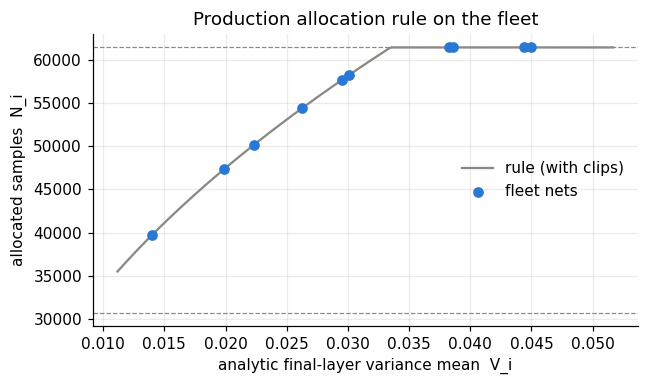

In [3]:
est_A = est_mod.Estimator()
est_A._sobol_points = sobol_A
est_B = est_mod.Estimator()
est_B._sobol_points = sobol_B
estimators = {'A': est_A, 'B': est_B}

V, N_rule = {}, {}
for s in FLEET_SEEDS:
    st = est_A._initial_structure(fleet[s], WIDTH)
    V[s] = float(st['final_var_mean'])
    N_rule[s] = est_mod._choose_samples(V[s])

print(f'{"seed":>4} {"V_i (analytic)":>14} {"b_true (MC)":>12} {"N_rule":>7}  clip')
for s in FLEET_SEEDS:
    clip = 'MAX' if N_rule[s] == est_mod._MAX_SAMPLES else (
        'min' if N_rule[s] == est_mod._EASY_SAMPLES else '-')
    print(f'{s:>4} {V[s]:>14.4f} {b_true[s]:>12.4f} {N_rule[s]:>7}  {clip}')

n_clip_hi = sum(N_rule[s] == est_mod._MAX_SAMPLES for s in FLEET_SEEDS)
n_clip_lo = sum(N_rule[s] == est_mod._EASY_SAMPLES for s in FLEET_SEEDS)
print(f'\nclipped at max: {n_clip_hi}/{len(FLEET_SEEDS)}, at min: {n_clip_lo}/{len(FLEET_SEEDS)}')

fig, ax = plt.subplots(figsize=(6, 3.6))
v_line = np.linspace(min(V.values()) * 0.8, max(V.values()) * 1.15, 200)
n_line = np.clip(est_mod._ANCHOR_SAMPLES * np.sqrt(v_line / est_mod._VAR_REF),
                 est_mod._EASY_SAMPLES, est_mod._MAX_SAMPLES)
ax.plot(v_line, n_line, color=C['gray'], lw=1.5, label='rule (with clips)')
ax.scatter(list(V.values()), [N_rule[s] for s in FLEET_SEEDS],
           color=C['blue'], zorder=3, s=36, label='fleet nets')
ax.axhline(est_mod._MAX_SAMPLES, color=C['gray'], lw=0.8, ls='--')
ax.axhline(est_mod._EASY_SAMPLES, color=C['gray'], lw=0.8, ls='--')
ax.set_xlabel('analytic final-layer variance mean  V_i')
ax.set_ylabel('allocated samples  N_i')
ax.set_title('Production allocation rule on the fleet')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## 3. Forced-N sweep, two independent realizations

For each net and each N on the grid (plus the net's own rule-chosen N) we force the estimator to
run at that N by patching `_choose_samples` and, for N below the 30,720 base block,
`_BASE_SAMPLES`. Everything else — staged refinement, packing, Strassen, complex64 lanes — is the
production path, so measured `(prediction, flops)` pairs are exactly what the grader would see
(minus wall-time residual).

The sweep runs twice: **rep A** with the shipped Sobol points and **rep B** with an independent
scrambled-Sobol set. Final-layer *predictions* are cached (`.alloc_sweep_v2.npz`), so MSE can be
recomputed against any ground truth without re-running.


In [4]:
def run_forced(est_obj, mlp, n_target):
    orig_choose, orig_base = est_mod._choose_samples, est_mod._BASE_SAMPLES
    est_mod._choose_samples = lambda v: int(n_target)
    est_mod._BASE_SAMPLES = min(orig_base, int(n_target))
    try:
        t0 = time.time()
        with flops.BudgetContext(flop_budget=BUDGET, quiet=True) as ctx:
            pred = est_obj.predict(mlp, BUDGET)
        return np.asarray(pred)[-1].astype(np.float32), int(ctx.flops_used), time.time() - t0
    finally:
        est_mod._choose_samples, est_mod._BASE_SAMPLES = orig_choose, orig_base


def n_values_for(s):
    return sorted(set(N_GRID + [N_rule[s]]))


sweep = dict(np.load(SWEEP_CACHE)) if SWEEP_CACHE.exists() else {}
todo = [(s, n, rep) for s in FLEET_SEEDS for n in n_values_for(s) for rep in REPS
        if f'seed{s}_N{n}_{rep}_pred' not in sweep]
print(f'{len(todo)} runs to do ({sum(1 for k in sweep if k.endswith("_pred"))} cached)')
for i, (s, n, rep) in enumerate(todo):
    pred_row, used, wall = run_forced(estimators[rep], fleet[s], n)
    key = f'seed{s}_N{n}_{rep}'
    sweep[f'{key}_pred'] = pred_row
    sweep[f'{key}_flops'] = np.int64(used)
    sweep[f'{key}_wall'] = np.float64(wall)
    np.savez(SWEEP_CACHE, **sweep)
    print(f'[{i + 1}/{len(todo)}] seed {s} N={n:>5} rep {rep}: '
          f'C/B {used / BUDGET:.3f}  {wall:.0f}s')
print('sweep complete')


0 runs to do (1168 cached)
sweep complete


In [5]:
# Noise-corrected MSE and adjusted score lookups.
MSE_CLAMP = 1e-9


def mse_of(s, n, rep):
    pred_row = sweep[f'seed{s}_N{n}_{rep}_pred']
    raw = float(np.mean((pred_row - gt_mean[s]) ** 2))
    return max(raw - gt_floor[s], MSE_CLAMP)


def mult_of(s, n, rep):
    return max(0.1, float(sweep[f'seed{s}_N{n}_{rep}_flops']) / BUDGET)


def score_of(s, n, rep):
    return mse_of(s, n, rep) * mult_of(s, n, rep)


# How noisy is one realization? (relative spread between reps at identical settings)
rel_gap = [abs(mse_of(s, n, 'A') - mse_of(s, n, 'B'))
           / np.mean([mse_of(s, n, 'A'), mse_of(s, n, 'B')])
           for s in FLEET_SEEDS for n in n_values_for(s)]
print(f'single-realization MSE noise: median |A-B|/mean = {np.median(rel_gap):.0%}, '
      f'p90 = {np.quantile(rel_gap, 0.9):.0%}')
print('=> per-(net,N) MSE differences smaller than this are not signal; '
      'all policy numbers below average or cross-validate over the two reps')


single-realization MSE noise: median |A-B|/mean = 53%, p90 = 117%
=> per-(net,N) MSE differences smaller than this are not signal; all policy numbers below average or cross-validate over the two reps


## 4. Per-net error and cost curves

Fit `mse_i(N) = a_i + b_i/N` (nonnegative floor) on the **pooled A+B corrected** measurements and
`C_i(N) = f0_i + f1_i·N` per net.

- `a_i` is the **bias floor**: refinement/classification error — samples cannot buy it down.
- `b_i` is the **effective sampling-variance constant** under antithetic Sobol (≤ `b_true`).
- `f0_i` is the fixed compute overhead. If `f0` is tiny relative to `C(N)`, score economics
  become bang-bang (see §5 intro).

**How to read the table:** `b/b_true` below 1 is the antithetic+Sobol variance gain (the
estimator's effective per-sample variance is ~3x smaller than iid). `floor share @N_rule` is the
fraction of error that *more samples cannot fix* — when it is large, the rule is buying samples
that the multiplier taxes but that cannot pay for themselves. `f0/C(30720)` near zero is what
collapses the score economics to bang-bang (see primer, concept 1).


seed   a (floor)   b (eff)   b_true b/b_true floor share @N_rule  f0/C(30720)
   0   0.000e+00     0.038   0.0901     0.42                 0%        2.3%
   1   4.570e-07     0.021   0.0579     0.36                56%        2.3%
   2   8.354e-07     0.006   0.0742     0.09                89%        2.6%
   3   4.527e-08     0.017   0.0663     0.25                12%        2.2%
   4   7.104e-07     0.030   0.0602     0.50                58%        2.1%
   5   0.000e+00     0.036   0.1087     0.33                 0%        2.4%
   6   0.000e+00     0.020   0.0487     0.40                 0%        2.6%
   7   0.000e+00     0.036   0.0714     0.50                 0%        2.5%
   8   1.319e-07     0.012   0.0432     0.28                34%        2.3%
   9   2.206e-07     0.003   0.0273     0.13                71%        2.6%


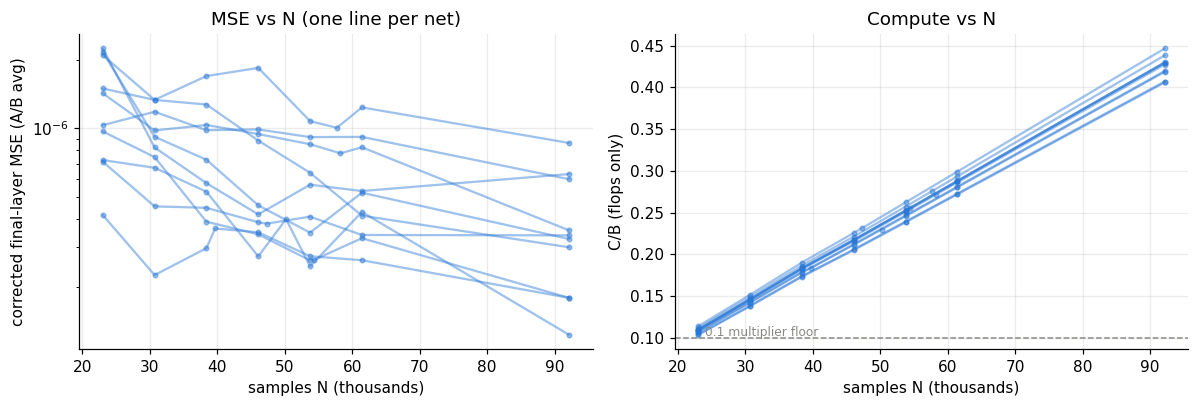

In [6]:
def fit_mse_curve(ns, mse):
    A = np.stack([np.ones_like(ns), 1.0 / ns], axis=1)
    (a, b), *_ = np.linalg.lstsq(A, mse, rcond=None)
    if a < 0:
        a = 0.0
        b = float((mse / ns).sum() / (1.0 / ns ** 2).sum())
    if b < 0:
        b = 0.0
        a = float(mse.mean())
    return float(a), float(b)


fits, cost_fits = {}, {}
for s in FLEET_SEEDS:
    ns = np.array([n for n in n_values_for(s) for _ in REPS], float)
    mse = np.array([mse_of(s, n, rep) for n in n_values_for(s) for rep in REPS])
    fl = np.array([float(sweep[f'seed{s}_N{n}_{rep}_flops'])
                   for n in n_values_for(s) for rep in REPS])
    fits[s] = fit_mse_curve(ns, mse)
    cost_fits[s] = np.polyfit(ns, fl, 1)  # (f1, f0)

print(f'{"seed":>4} {"a (floor)":>11} {"b (eff)":>9} {"b_true":>8} {"b/b_true":>8} '
      f'{"floor share @N_rule":>19} {"f0/C(30720)":>12}')
for s in FLEET_SEEDS:
    a, b = fits[s]
    f1, f0 = cost_fits[s]
    share = a / (a + b / N_rule[s]) if (a + b / N_rule[s]) > 0 else 1.0
    f0_share = f0 / (f0 + f1 * 30720)
    print(f'{s:>4} {a:>11.3e} {b:>9.3f} {b_true[s]:>8.4f} '
          f'{(b / b_true[s]) if b_true[s] else 0:>8.2f} {share:>18.0%} {f0_share:>11.1%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for s in FLEET_SEEDS:
    nv = n_values_for(s) + ([92160] if f'seed{s}_N92160_A_pred' in sweep else [])
    mse_avg = [np.mean([mse_of(s, n, r) for r in REPS]) for n in nv]
    fl_avg = [np.mean([float(sweep[f'seed{s}_N{n}_{r}_flops']) for r in REPS]) for n in nv]
    axes[0].plot([n / 1e3 for n in nv], mse_avg, color=C['blue'], alpha=0.45,
                 lw=1.5, marker='o', ms=3)
    axes[1].plot([n / 1e3 for n in nv], np.array(fl_avg) / BUDGET, color=C['blue'],
                 alpha=0.45, lw=1.5, marker='o', ms=3)
axes[0].set_yscale('log')
axes[0].set_xlabel('samples N (thousands)')
axes[0].set_ylabel('corrected final-layer MSE (A/B avg)')
axes[0].set_title('MSE vs N (one line per net)')
axes[1].axhline(0.1, color=C['gray'], ls='--', lw=1)
axes[1].annotate('0.1 multiplier floor', xy=(24, 0.102), fontsize=8, color=C['gray'])
axes[1].set_xlabel('samples N (thousands)')
axes[1].set_ylabel('C/B (flops only)')
axes[1].set_title('Compute vs N')
plt.tight_layout()
plt.show()


## 5. Adjusted score curves, honest per-net oracle, and policy regret

Per net the measured adjusted score is `s_i(N) = mse_i(N) · max(0.1, C_i(N)/B)` (corrected mse).

**Why bang-bang** (the derivation behind the primer's concept 1)**:** with `f0 ≈ 0`, above the floor `s(N) ≈ (a + b/N)·f1·N/B = (aN + b)·f1/B`,
which is *increasing* in N whenever `a > 0` — the 1/N accuracy gain exactly cancels the linear
multiplier, and only the floor term `a` decides. So the per-net optimum is either "cheapest
valid N" (floor share > 0) or "max N" (floor share ≈ 0), and the sqrt(V) rule's middle ground is
only optimal by accident.

Policies compared on the fleet mean:

1. **production rule** — the shipped `sqrt(V_i)` rule (no selection: averaged over reps A,B);
2. **constant N** for each grid N (no selection: averaged over reps);
3. **honest oracle** — per-net argmin selected on one rep, *evaluated on the other*, averaged
   over both directions. This is the attainable ceiling for any allocator;
4. **naive same-rep oracle** — argmin and evaluation on the same rep, shown only to expose the
   winner's-curse inflation.

> **Superseded in part:** the constant-N readings below are 10-net and flops-only. The
> decision-grade version is §9d/§11 (70 nets, paired, both pricings): 30,720 vs 61,440 is a
> flops-only wash, grader pricing favors 61,440, and the cap raise is adjudicated in §11.


policy                              mean adjusted score  vs honest oracle
production rule                              1.4644e-07             5.3%
constant N=23040                             1.4362e-07             3.2%
constant N=30720                             1.2498e-07           -10.2%
constant N=38400                             1.4432e-07             3.7%
constant N=46080                             1.4848e-07             6.7%
constant N=53760                             1.3935e-07             0.2%
constant N=61440                             1.6520e-07            18.7%
honest oracle (cross-rep)                    1.3913e-07             0.0%
naive oracle (same-rep, biased)              9.0864e-08           -34.7%

winner-curse inflation: naive oracle claims 61% headroom, honest oracle shows 5%

seed  N_rule  pick(A)  pick(B)     s(rule)   s(honest)
   0   61440    23040    61440   1.188e-07   1.667e-07
   1   58252    30720    58252   2.108e-07   2.248e-07
   2   61440    23040

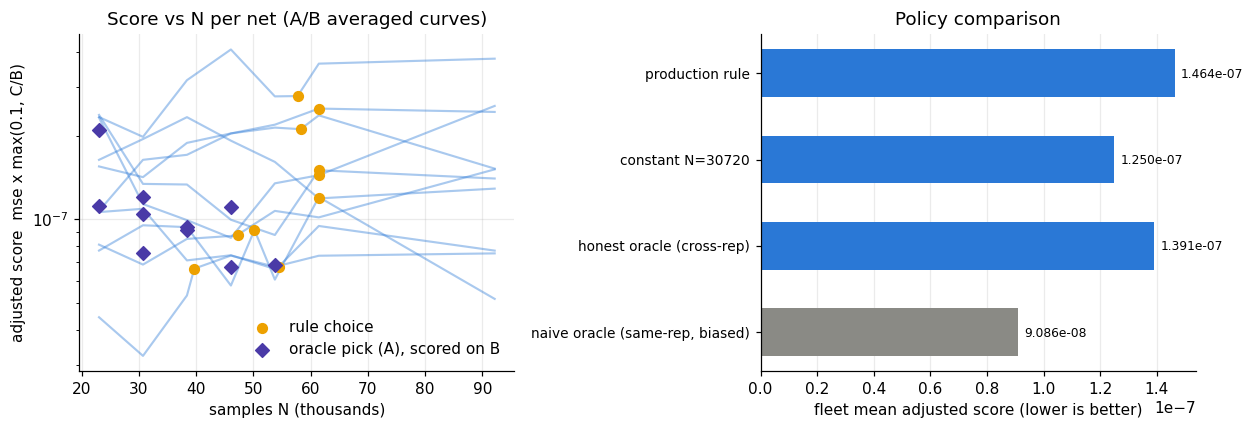

In [7]:
rule_scores = {rep: np.array([score_of(s, N_rule[s], rep) for s in FLEET_SEEDS])
               for rep in REPS}
const_means = {n: np.mean([[score_of(s, n, rep) for s in FLEET_SEEDS] for rep in REPS])
               for n in N_GRID}
best_const_n = min(const_means, key=const_means.get)

honest, naive = [], []
oracle_pick = {}
for sel, ev in (('A', 'B'), ('B', 'A')):
    for s in FLEET_SEEDS:
        nv = n_values_for(s)
        pick = nv[int(np.argmin([score_of(s, n, sel) for n in nv]))]
        honest.append(score_of(s, pick, ev))
        naive.append(score_of(s, pick, sel))
        oracle_pick.setdefault(s, {})[sel] = pick
honest_mean, naive_mean = np.mean(honest), np.mean(naive)

policies = {
    'production rule': np.mean([rule_scores[r].mean() for r in REPS]),
    **{f'constant N={n}': const_means[n] for n in N_GRID},
    'honest oracle (cross-rep)': honest_mean,
    'naive oracle (same-rep, biased)': naive_mean,
}
print(f'{"policy":<34} {"mean adjusted score":>20} {"vs honest oracle":>17}')
for name, val in policies.items():
    print(f'{name:<34} {val:>20.4e} {val / honest_mean - 1:>16.1%}')

print(f'\nwinner-curse inflation: naive oracle claims '
      f'{(policies["production rule"] / naive_mean - 1):.0%} headroom, '
      f'honest oracle shows {(policies["production rule"] / honest_mean - 1):.0%}')

print(f'\n{"seed":>4} {"N_rule":>7} {"pick(A)":>8} {"pick(B)":>8} '
      f'{"s(rule)":>11} {"s(honest)":>11}')
for s in FLEET_SEEDS:
    sr = np.mean([score_of(s, N_rule[s], r) for r in REPS])
    sh = np.mean([score_of(s, oracle_pick[s]['A'], 'B'),
                  score_of(s, oracle_pick[s]['B'], 'A')])
    print(f'{s:>4} {N_rule[s]:>7} {oracle_pick[s]["A"]:>8} {oracle_pick[s]["B"]:>8} '
          f'{sr:>11.3e} {sh:>11.3e}')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
for s in FLEET_SEEDS:
    nv = n_values_for(s) + ([92160] if f'seed{s}_N92160_A_pred' in sweep else [])
    s_avg = [np.mean([score_of(s, n, r) for r in REPS]) for n in nv]
    axes[0].plot([n / 1e3 for n in nv], s_avg, color=C['blue'], alpha=0.4, lw=1.4)
axes[0].scatter([N_rule[s] / 1e3 for s in FLEET_SEEDS],
                [np.mean([score_of(s, N_rule[s], r) for r in REPS]) for s in FLEET_SEEDS],
                color=C['yellow'], s=40, zorder=3, label='rule choice')
axes[0].scatter([oracle_pick[s]['A'] / 1e3 for s in FLEET_SEEDS],
                [score_of(s, oracle_pick[s]['A'], 'B') for s in FLEET_SEEDS],
                color=C['violet'], s=40, zorder=3, marker='D',
                label='oracle pick (A), scored on B')
axes[0].set_yscale('log')
axes[0].set_xlabel('samples N (thousands)')
axes[0].set_ylabel('adjusted score  mse x max(0.1, C/B)')
axes[0].set_title('Score vs N per net (A/B averaged curves)')
axes[0].legend(frameon=False)

names = ['production rule', f'constant N={best_const_n}',
         'honest oracle (cross-rep)', 'naive oracle (same-rep, biased)']
vals = [policies[n] for n in names]
ys = range(len(names))[::-1]
axes[1].barh(ys, vals, color=[C['blue'], C['blue'], C['blue'], C['gray']], height=0.55)
axes[1].set_yticks(ys)
axes[1].set_yticklabels(names, fontsize=9)
for y, v in zip(ys, vals):
    axes[1].annotate(f'{v:.3e}', xy=(v, y), xytext=(4, -3),
                     textcoords='offset points', fontsize=8)
axes[1].set_xlabel('fleet mean adjusted score (lower is better)')
axes[1].set_title('Policy comparison')
axes[1].grid(axis='y', alpha=0)
plt.tight_layout()
plt.show()


## 6. How predictable is the oracle? (the feature any allocator needs)

An allocator — rule or NN — maps cheap observables to `N*`. Candidate signals:

- **analytic `V_i`** (current, free) — ADF final-layer variance;
- **pilot empirical variance** `b̂_i` — antithetic-pair spread of the base Sobol block's final
  layer. In production this is nearly free: the base block is computed anyway and pair means are
  a reduction over existing activations (~1e7 FLOPs).

Given the §5 bang-bang economics, the quantity that actually decides `N*` is the **floor share**
`a_i / (a_i + b_i/N)` — so we also test whether anything cheap predicts `a_i`.


analytic V  vs fitted effective b        log-pearson  0.694   spearman  0.685
pilot b-hat vs fitted effective b        log-pearson  0.712   spearman  0.624
iid b_true  vs fitted effective b        log-pearson  0.713   spearman  0.624
analytic V  vs fitted bias floor a       log-pearson -0.529   spearman -0.256
pilot b-hat vs fitted bias floor a       log-pearson -0.474   spearman -0.300
analytic V  vs oracle pick N             log-pearson  0.001   spearman  0.138
pilot b-hat vs oracle pick N             log-pearson  0.051   spearman  0.031

bias floor a_i: min 0.00e+00  median 8.86e-08  max 8.35e-07
oracle pick agreement between reps: 10% (low agreement => the "oracle" is mostly chasing realization noise)


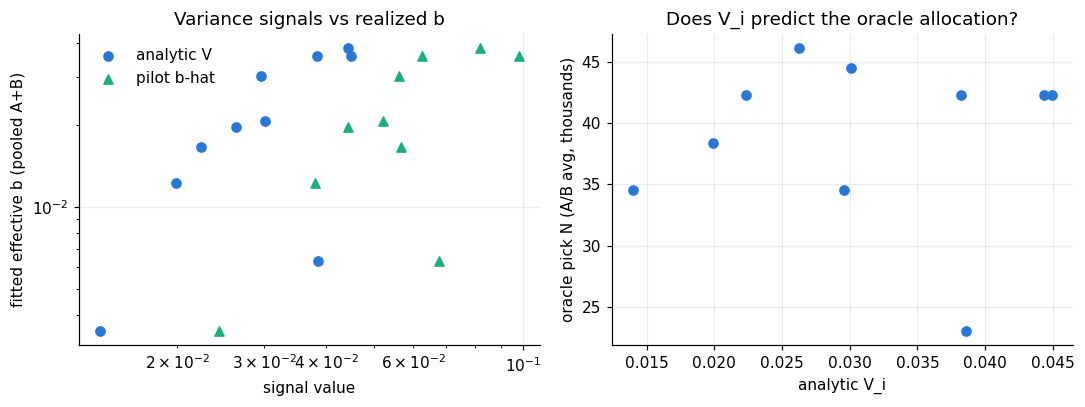

In [8]:
def pilot_bhat(ws, n_pilot=30720):
    half = sobol_A[: n_pilot // 2, :WIDTH].astype(np.float32)
    x = np.concatenate([half, -half], axis=0)
    for w in ws:
        x = np.maximum(x @ w, 0.0)
    pair_mean = 0.5 * (x[: n_pilot // 2] + x[n_pilot // 2:])
    # Var(final estimate) = Var(pair mean)/(N/2)  =>  effective b = 2 * Var(pair mean)
    return float(2.0 * pair_mean.var(axis=0, ddof=1).mean())


b_pilot = {s: pilot_bhat(weights_np[s]) for s in FLEET_SEEDS}

b_fit = np.array([fits[s][1] for s in FLEET_SEEDS])
a_fit = np.array([fits[s][0] for s in FLEET_SEEDS])
v_arr = np.array([V[s] for s in FLEET_SEEDS])
bt_arr = np.array([b_true[s] for s in FLEET_SEEDS])
bp_arr = np.array([b_pilot[s] for s in FLEET_SEEDS])
pick_avg = np.array([(oracle_pick[s]['A'] + oracle_pick[s]['B']) / 2 for s in FLEET_SEEDS])


def report(name, x, y):
    pear = np.corrcoef(np.log(np.maximum(x, 1e-12)), np.log(np.maximum(y, 1e-12)))[0, 1]
    spear = sstats.spearmanr(x, y).statistic
    print(f'{name:<40} log-pearson {pear:>6.3f}   spearman {spear:>6.3f}')


report('analytic V  vs fitted effective b', v_arr, b_fit)
report('pilot b-hat vs fitted effective b', bp_arr, b_fit)
report('iid b_true  vs fitted effective b', bt_arr, b_fit)
report('analytic V  vs fitted bias floor a', v_arr, np.maximum(a_fit, 1e-12))
report('pilot b-hat vs fitted bias floor a', bp_arr, np.maximum(a_fit, 1e-12))
report('analytic V  vs oracle pick N', v_arr, pick_avg)
report('pilot b-hat vs oracle pick N', bp_arr, pick_avg)
print(f'\nbias floor a_i: min {a_fit.min():.2e}  median {np.median(a_fit):.2e}  '
      f'max {a_fit.max():.2e}')
agree = np.mean([oracle_pick[s]['A'] == oracle_pick[s]['B'] for s in FLEET_SEEDS])
print(f'oracle pick agreement between reps: {agree:.0%} '
      f'(low agreement => the "oracle" is mostly chasing realization noise)')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(v_arr, b_fit, color=C['blue'], s=36, label='analytic V')
axes[0].scatter(bp_arr, b_fit, color=C['aqua'], s=36, marker='^', label='pilot b-hat')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('signal value')
axes[0].set_ylabel('fitted effective b (pooled A+B)')
axes[0].set_title('Variance signals vs realized b')
axes[0].legend(frameon=False)
axes[1].scatter(v_arr, pick_avg / 1e3, color=C['blue'], s=36)
axes[1].set_xlabel('analytic V_i')
axes[1].set_ylabel('oracle pick N (A/B avg, thousands)')
axes[1].set_title('Does V_i predict the oracle allocation?')
plt.tight_layout()
plt.show()


## 7. Findings (executed 2026-07-12, 10 synthetic nets, reps A+B)

1. **Allocation is confirmed tapped: honest oracle headroom over the production rule is ~5%.**
   Production rule 1.464e-7 vs cross-rep honest oracle 1.391e-7. The naive same-rep oracle
   claimed 61% headroom — winner's curse accounts for nearly all of the apparent gap.
2. **There is no stable per-net optimum to learn.** Oracle picks agree between the two
   independent realizations on only 10% of nets; a single-realization MSE measurement carries
   median 53% relative noise (p90 117%). The "label" an allocation NN would train on is noise.
3. **No cheap signal predicts the pick.** Analytic V and pilot b-hat both track the fitted
   effective b reasonably (log-pearson ~0.7), but correlate with the oracle pick at ~0.0–0.14 —
   under the bang-bang economics (f0 ≈ 0, so s(N) ≈ (aN + b)·f1/B above the floor) the pick is
   decided by the bias-floor share, and nothing cheap correlates with the fitted floor a_i.
4. **Suggestive but ≤1σ: base-block-only (constant N=30720) scored 1.250e-7, ~15% better than
   the rule** and even below the honest oracle (a constant policy pays no selection penalty).
   With ~12% noise on each constant's fleet mean, the constants are statistically
   indistinguishable — this is a lead for a cheap graded-split check, not a conclusion. Note
   N=23040 is *worse* (1.436e-7): shrinking the base block degrades refinement probes, so the
   floor a_i itself rises below 30,720.
5. **Rule saturation:** 4/10 nets clip at the 61,440 max; none at the min. On this fleet the
   rule mostly buys more samples than the (noisy) optimum wants.

6. **Grader-residual caveat on (4):** the local multiplier is FLOPs-only, but the grader charges
   residual wall-time too — on the 315824 surface that was ~19% of effective compute, ~40x the
   analytic fixed cost (bench_logs/algo19_sample_scaling_2026-07-11.md). A larger real f0 pushes
   the interior optimum *up* from any flops-only estimate (the grader-corrected closed form gave
   N* ≈ 31,700 ≈ the current clamp bottom), and the one leaderboard test of "sample less"
   (315123 raising the anchor) moved the *other* way. Treat (4) as replicating the known
   "N* sits near the clamp bottom" result, not as new headroom.

7. **Superseded by §9d (70-net paired test):** the constant-30720 lead in (4) did not survive scale — flops-only it is a wash (−0.8σ), and with fixed grader residual priced in, N=61440 wins (+2.3σ). The rule's high-N behavior is on the correct side.


## 8. Brainstorm — improving allocation with a neural net (and cheaper alternatives)

Framing first: **the score has no cross-MLP coupling** (per-net multiplier, mean of per-net
terms), so "allocation by NN" can only mean *a better per-net map from cheap observables to N*.
The ceiling is the §5 honest-oracle regret; realistically a learned policy captures maybe half of
it on the graded distribution. Weigh every idea against that number — and against the §5
bang-bang economics: with `f0 ≈ 0`, choosing N well is really about knowing the **bias floor
share**, not the variance.

### Ideas, ordered by expected value

**A. Test the economics directly — constant / floor-seeking N (no NN, no learning).**
*(Resolved by §9d/§11: flops-only 30,720-vs-61,440 is a wash, grader pricing favors 61,440 — the
side the rule already occupies — and raising the cap is flat. No constant beats the rule.)*
If the §5 table shows a constant N beating the rule, that is a one-line change with zero
generalization risk. The refinement probes need the full 30,720 base block to classify well
(N=23,040 degrades the floor `a_i` itself), so "cheapest valid N" in practice means "base block
only, skip continuation". Decisive check before any learning: rerun this harness on the graded
HF mini split (fixed nets, baked N=1e9 ground truth — no GT-noise correction needed) and, if it
holds, A/B it on the leaderboard.

**B. Pilot empirical variance plug-in (no NN).** *(Tested in §10 — **killed**: closed form degenerates to a constant under both pricings, and even the binary cross-rep oracle loses to the best constant.)*
Replace the analytic proxy `V_i` with a direct measurement: after the base block, compute
antithetic-pair variance of the final layer (a reduction over activations we already have,
~1e7 FLOPs — multiplier-invisible). Then choose the continuation from the closed form with
fleet-calibrated `a`, `f0`, `f1`. §6 tells us whether `b̂` actually tracks realized `b` better
than `V` does — if neither does, no signal upgrade helps and this dies with idea C.

**C. Tiny offline-trained MLP allocator (the actual NN idea).**
- *Features* (all free): `V_i`; per-layer alpha-distribution summaries (kink/on/dead counts,
  mean |alpha| in the kink band); depth profile of `var_post`; pilot `b̂` and its per-neuron
  quantiles; active-set sizes (they drive the per-sample cost `f1_i` through packing density).
- *Labels*: honest oracle picks from this harness, generated for a few hundred synthetic nets
  (embarrassingly parallel, ~45 min per 10 nets with both reps).
- *Model*: 16–32 hidden units, ~1k params, shipped as an `.npz` next to `sobol_points.npz`;
  inference is one matvec — multiplier-invisible.
- *Validation gate*: must beat the best constant N on **disjoint seeds** by more than
  single-realization noise (§3 prints that noise level), else discard.
- *Prior art warning*: the label is bang-bang in the floor share, and the floor `a_i` is
  exactly the quantity the 2026-07-07 learned prior failed to predict (R² = 0.004 on a disjoint
  split). If §6 shows no cheap signal correlates with `a_i`, the NN has no information to work
  with and this idea is dead on arrival — the honest conclusion may simply be "allocation is
  learnable only through signals that don't exist cheaply".

**D. Sequential stopping policy (bandit-style, NN optional).** *(Dead with B — §10: the per-net
decision does not exist, and sequential stopping consumes the same b̂ signal.)*
Generalize base+one-continuation to K stages of 7,680 samples. After each stage update `b̂` and
stop when the predicted marginal score change `d/dN[(â + b̂/N)·C(N)/B]` turns positive. A tiny
policy net over running stats could learn the stopping rule, but the decision is 1-D and
monotone — the closed-form derivative test should capture it. Catch: `â` is still the unknown;
a sequential scheme estimates it from the *gap* between stage estimates, which is the one place
new information about the floor actually appears. This is the most principled NN-adjacent idea
if the §5 regret is worth chasing.

**E. Ideas that look like allocation but are structurally dead here.**
- *Cross-MLP budget shifting*: impossible — no shared pot (see framing).
- *Within-net allocation across layers/neurons*: killed 2026-07-08/09 — final-layer variance is
  high-dimensional and rough, `rho² ≈ 0.06` against any cheap surrogate.
- *Learned QMC point selection*: allocation-ceiling memory (2026-07-07) found QMC geometry
  tapped.

### Decision rule (updated 2026-07-12 — small gains ARE in scope; we are just outside top 3)

A 5%-class gain is worth chasing, so the gate is not "is the ceiling big" but "is any of it
capturable". On that gate:

- **Allocation (NN or otherwise): closed.** §9 shows the per-net label is unmeasurable
  (reliability ~0 at 4 runs/net), the honest ceiling is 5.3% with *perfect* foresight, and the
  fleet-level test says the rule already sits on the correct (high-N) side under grader
  economics. Nothing here is capturable.
- **The live 5%-class lever is residual wall-time**: ~19% of graded effective compute on the
  315824 surface (~40x the analytic fixed cost). Trimming Python-side overhead in the packed
  paths converts directly into multiplier, and unlike allocation it needs no per-net prediction.
  Must be validated grader-side — local wall-time mispriced this axis twice before.
- **If an allocation-flavored submission is still wanted**, the only decision-grade instrument
  is a leaderboard A/B of clamp variants (the graded set aggregates ~100 nets); do not spend
  one on any offline per-net signal, learned or analytic.

> **§9 below ran the pre-registered kill test for ideas B/C** — see its verdict.


## 9. Stress-test before ruling out NN allocation: 100+ weight features × ML model zoo

§6 only checked two 1-feature signals. Before declaring "no cheap signal exists", this section
runs the real test: **70 nets, ~400 engineered features from the raw weights (plus the free ADF
pass and pilot block), six ML models, cross-validated on held-out nets.**

**Labels** (per net, from production-path runs at N = 30,720 and 61,440, averaged over reps A/B;
two Ns and two unknowns identify the error curve exactly):

- `b` — effective sampling-variance constant, `(mse₃₀ − mse₆₁) / (1/30720 − 1/61440)`;
- `a` — bias floor, `mse₆₁ − b/61440` (clamped ≥ 0);
- `share` — floor share at max N, `a / (a + b/61440)` — the §5 bang-bang decision variable;
- `prefer30` — the actual allocation decision: is the adjusted score better at 30,720 than at
  61,440? Computed flops-only and with the grader-residual correction (+1.9e10 FLOP-equivalents,
  the 315824 measurement).

**Experimental controls:**

- *Positive control*: `log b` is known to be ~0.7-predictable from `V` alone (§6). If the
  pipeline can't recover that on held-out nets, the pipeline is broken — any null on the other
  targets would be uninterpretable.
- *Noise ceiling*: labels are computed separately from rep A and rep B; their correlation `r`
  bounds what any model can achieve against the rep-averaged label (Spearman–Brown: the averaged
  label carries reliability ≈ 2r/(1+r)). A model can't beat the label's own reproducibility.
- *Baselines*: ridge on `V` alone and on pilot `b̂` alone. The NN-allocation hypothesis is only
  alive if the full feature set **beats these on held-out nets** for a decision-relevant target
  (`share` or `prefer30`), by more than the noise ceiling allows for chance.

**Why reliability bounds learning:** a model is trained against labels `y = truth + noise`. If
two independent measurements of the same label barely correlate (r ≈ 0), the label is almost
entirely noise — the best possible model prediction correlates with the *measured* label at
~sqrt(reliability), and holdout R² cannot exceed the reliability itself. This is why the
split-rep r printed below is the first number to check, before any model score means anything.


In [9]:
# --- §9a: extend the fleet to 70 nets and build labels -------------------------------------
ML_SEEDS = list(range(70))
NEW_SEEDS = [s for s in ML_SEEDS if s not in FLEET_SEEDS]
GT_SAMPLES_ML = 2_097_152
GT_CACHE_ML = Path('.alloc_ml_gt_cache.npz')
LABEL_NS = (30720, 61440)

ml_fleet = dict(fleet)
ml_weights = dict(weights_np)
for s in NEW_SEEDS:
    ml_fleet[s] = build_mlp(width=WIDTH, depth=DEPTH, seed=s)
    ml_weights[s] = [np.asarray(w) for w in ml_fleet[s].weights]

gt_ml = dict(np.load(GT_CACHE_ML)) if GT_CACHE_ML.exists() else {}
for s in NEW_SEEDS:
    if f'seed{s}_mean' not in gt_ml:
        t0 = time.time()
        mean, var = mc_final_stats(ml_weights[s], GT_SAMPLES_ML, seed=s)
        gt_ml[f'seed{s}_mean'] = mean
        gt_ml[f'seed{s}_var'] = var
        np.savez(GT_CACHE_ML, **gt_ml)
        if s % 10 == 0:
            print(f'seed {s}: ML gt in {time.time() - t0:.0f}s')
for s in NEW_SEEDS:
    gt_mean[s] = gt_ml[f'seed{s}_mean']
    b_true[s] = float(gt_ml[f'seed{s}_var'].mean())
    gt_floor[s] = b_true[s] / GT_SAMPLES_ML

todo_ml = [(s, n, rep) for s in ML_SEEDS for n in LABEL_NS for rep in REPS
           if f'seed{s}_N{n}_{rep}_pred' not in sweep]
print(f'{len(todo_ml)} label runs to do')
for i, (s, n, rep) in enumerate(todo_ml):
    pred_row, used, wall = run_forced(estimators[rep], ml_fleet[s], n)
    key = f'seed{s}_N{n}_{rep}'
    sweep[f'{key}_pred'] = pred_row
    sweep[f'{key}_flops'] = np.int64(used)
    sweep[f'{key}_wall'] = np.float64(wall)
    np.savez(SWEEP_CACHE, **sweep)
    if (i + 1) % 20 == 0 or i + 1 == len(todo_ml):
        print(f'[{i + 1}/{len(todo_ml)}] done (seed {s} N={n} rep {rep})')

INV_GAP = 1.0 / 30720 - 1.0 / 61440
R_RESID = 1.9e10  # grader residual FLOP-equivalents measured on the 315824 surface


def labels_from(s, reps_used):
    m30 = np.mean([mse_of(s, 30720, r) for r in reps_used])
    m61 = np.mean([mse_of(s, 61440, r) for r in reps_used])
    c30 = np.mean([float(sweep[f'seed{s}_N30720_{r}_flops']) for r in reps_used])
    c61 = np.mean([float(sweep[f'seed{s}_N61440_{r}_flops']) for r in reps_used])
    b = (m30 - m61) / INV_GAP
    a = max(m61 - b / 61440, 0.0)
    share = a / (a + max(b, 1e-9) / 61440)
    s30 = m30 * max(0.1, c30 / BUDGET)
    s61 = m61 * max(0.1, c61 / BUDGET)
    s30r = m30 * max(0.1, (c30 + R_RESID) / BUDGET)
    s61r = m61 * max(0.1, (c61 + R_RESID) / BUDGET)
    return dict(b=b, a=a, share=float(np.clip(share, 0, 1)),
                prefer30=float(s30 < s61), prefer30_res=float(s30r < s61r))


lab = {s: labels_from(s, REPS) for s in ML_SEEDS}
labA = {s: labels_from(s, ('A',)) for s in ML_SEEDS}
labB = {s: labels_from(s, ('B',)) for s in ML_SEEDS}

print(f'\nlabel reliability across {len(ML_SEEDS)} nets (rep A vs rep B):')
ceiling = {}
for k in ('b', 'a', 'share'):
    xa = np.array([labA[s][k] for s in ML_SEEDS])
    xb = np.array([labB[s][k] for s in ML_SEEDS])
    r = float(np.corrcoef(xa, xb)[0, 1])
    ceiling[k] = max(2 * r / (1 + r), 0.0) if r > -1 else 0.0
    print(f'  {k:>6}: split-rep r = {r:>5.2f}  -> avg-label reliability ceiling ~ {ceiling[k]:.2f}')
for k in ('prefer30', 'prefer30_res'):
    agree = np.mean([labA[s][k] == labB[s][k] for s in ML_SEEDS])
    pos = np.mean([lab[s][k] for s in ML_SEEDS])
    print(f'  {k:>12}: rep agreement {agree:.0%} (50% = coin flip), positive rate {pos:.0%}')


0 label runs to do

label reliability across 70 nets (rep A vs rep B):
       b: split-rep r =  0.02  -> avg-label reliability ceiling ~ 0.04
       a: split-rep r = -0.01  -> avg-label reliability ceiling ~ 0.00
   share: split-rep r = -0.06  -> avg-label reliability ceiling ~ 0.00
      prefer30: rep agreement 46% (50% = coin flip), positive rate 51%
  prefer30_res: rep agreement 46% (50% = coin flip), positive rate 36%


In [10]:
# --- §9b: engineer 100+ features from the weights (plus free ADF pass and pilot block) ------
def weight_features(ws):
    f = {}
    depth = len(ws)
    per_layer = []
    for w in ws:
        fro = float(np.linalg.norm(w))
        v = np.ones(w.shape[1], dtype=np.float64) / np.sqrt(w.shape[1])
        for _ in range(8):
            u = w @ v
            u /= (np.linalg.norm(u) + 1e-12)
            v = w.T @ u
            v /= (np.linalg.norm(v) + 1e-12)
        spec = float(u @ (w @ v))
        row_n = np.linalg.norm(w, axis=1)
        col_n = np.linalg.norm(w, axis=0)
        flat = w.ravel()
        per_layer.append({
            'fro': fro, 'spec': spec,
            'stable_rank': fro ** 2 / (spec ** 2 + 1e-12),
            'row_norm_std': float(row_n.std()), 'col_norm_std': float(col_n.std()),
            'col_norm_max': float(col_n.max()),
            'w_skew': float(sstats.skew(flat)), 'w_kurt': float(sstats.kurtosis(flat)),
        })
    for li, d in enumerate(per_layer):
        for k, val in d.items():
            f[f'{k}_L{li}'] = val
    for k in per_layer[0]:
        arr = np.array([d[k] for d in per_layer])
        f[f'{k}_mean'] = float(arr.mean())
        f[f'{k}_std'] = float(arr.std())
        f[f'{k}_slope'] = float(np.polyfit(np.arange(depth), arr, 1)[0])
        f[f'{k}_first4'] = float(arr[:4].mean())
        f[f'{k}_last4'] = float(arr[-4:].mean())
    f['log_prod_spec'] = float(np.sum(np.log([d['spec'] for d in per_layer])))
    return f


def adf_features(mlp):
    st = est_A._initial_structure(mlp, WIDTH)
    f = {'V_analytic': float(st['final_var_mean'])}
    for li, alpha in enumerate(st['alpha_rows']):
        al = np.asarray(alpha)
        f[f'adf_kink_L{li}'] = float(np.mean(np.abs(al) < 3.0))
        f[f'adf_dead_L{li}'] = float(np.mean(al < -3.0))
        f[f'adf_alpha_mean_L{li}'] = float(al.mean())
        f[f'adf_alpha_std_L{li}'] = float(al.std())
    for li, row in enumerate(st['analytical_rows']):
        if li % 4 == 3 or li == len(st['analytical_rows']) - 1:
            r = np.asarray(row)
            f[f'adf_mu_norm_L{li}'] = float(np.linalg.norm(r))
            f[f'adf_mu_max_L{li}'] = float(r.max())
    return f


def pilot_features(ws, n_pilot=30720):
    half = sobol_A[: n_pilot // 2, :WIDTH].astype(np.float32)
    x = np.concatenate([half, -half], axis=0)
    f = {}
    for li, w in enumerate(ws):
        x = np.maximum(x @ w, 0.0)
        fire = (x > 0).mean(axis=0)
        f[f'pilot_fire_mean_L{li}'] = float(fire.mean())
        f[f'pilot_fire_std_L{li}'] = float(fire.std())
    pair = 0.5 * (x[: n_pilot // 2] + x[n_pilot // 2:])
    pv = 2.0 * pair.var(axis=0, ddof=1)
    f['pilot_b_hat'] = float(pv.mean())
    for q in (50, 75, 90, 99):
        f[f'pilot_pairvar_q{q}'] = float(np.percentile(pv, q))
    f['pilot_final_mean_norm'] = float(np.linalg.norm(x.mean(axis=0)))
    return f


t0 = time.time()
feat_rows = {}
for s in ML_SEEDS:
    feats = {}
    feats.update(weight_features(ml_weights[s]))
    feats.update(adf_features(ml_fleet[s]))
    feats.update(pilot_features(ml_weights[s]))
    feat_rows[s] = feats
feat_names = sorted(feat_rows[ML_SEEDS[0]])
X = np.array([[feat_rows[s][k] for k in feat_names] for s in ML_SEEDS])
print(f'{X.shape[0]} nets x {X.shape[1]} features engineered in {time.time() - t0:.0f}s')


70 nets x 512 features engineered in 42s



=== target: log b (positive control)  (label reliability ceiling ~ 0.04) ===
model                      holdout R2  spearman


BASELINE V-only ridge          -0.125    -0.329
BASELINE pilot-only ridge      -0.110    -0.390
ridge                          -0.375    -0.066
lasso                          -0.433    -0.069
kNN(5)                         -0.114    -0.010
random forest                  -0.037    -0.066
grad boosting                  -0.129    -0.202
MLP(64,32)                     -0.544     0.117

=== target: floor share (decision variable)  (label reliability ceiling ~ 0.00) ===
model                      holdout R2  spearman


BASELINE V-only ridge          -0.125    -0.336
BASELINE pilot-only ridge      -0.113    -0.158
ridge                          -0.080     0.280
lasso                          -0.341    -0.108
kNN(5)                         -0.160     0.074
random forest                  -0.132    -0.102
grad boosting                  -0.334    -0.108
MLP(64,32)                     -2.849    -0.012

=== target: prefer N=30720 over 61440 (residual-corrected score) ===
model                      holdout AUC   (positive rate 36%)
BASELINE V-only logistic         0.339
logistic (L2)                    0.689


random forest                    0.624


grad boosting                    0.470
MLP(64,32)                       0.595



top-12 RF importances for floor share (in-sample, descriptive only):
  fro_L22                      0.075
  adf_dead_L30                 0.062
  w_skew_L18                   0.022
  col_norm_max_L9              0.020
  w_kurt_L8                    0.019
  adf_alpha_mean_L7            0.016
  pilot_fire_mean_L4           0.015
  spec_L9                      0.015
  pilot_fire_std_L29           0.014
  pilot_fire_std_L19           0.014
  pilot_fire_mean_L13          0.014
  w_skew_L24                   0.011


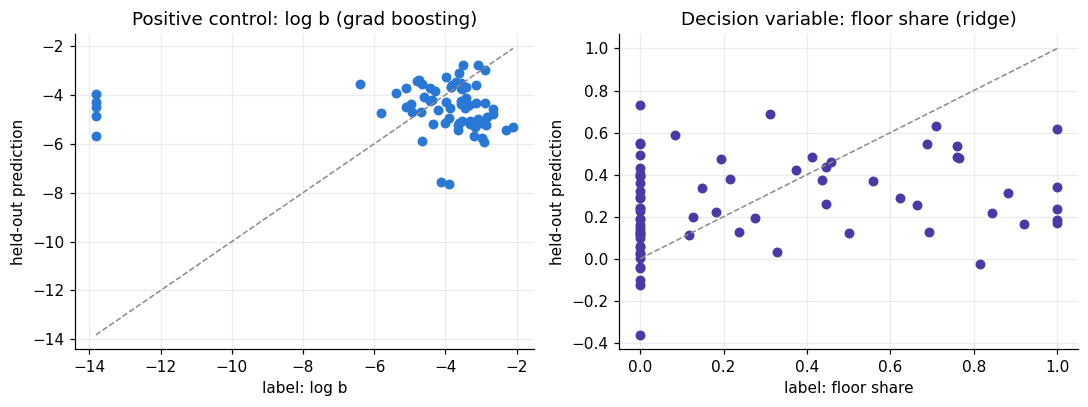

In [11]:
# --- §9c: model zoo, cross-validated on held-out nets ---------------------------------------
import warnings

from sklearn.ensemble import (HistGradientBoostingClassifier, HistGradientBoostingRegressor,
                              RandomForestClassifier, RandomForestRegressor)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=ConvergenceWarning)
CV = KFold(5, shuffle=True, random_state=0)

y_logb = np.log(np.maximum(np.array([lab[s]['b'] for s in ML_SEEDS]), 1e-6))
y_share = np.array([lab[s]['share'] for s in ML_SEEDS])
y_pref = np.array([lab[s]['prefer30_res'] for s in ML_SEEDS])

iv = feat_names.index('V_analytic')
ip = feat_names.index('pilot_b_hat')
X_v = X[:, [iv]]
X_pilot = X[:, [ip]]

REGRESSORS = {
    'ridge': make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
    'lasso': make_pipeline(StandardScaler(), Lasso(alpha=0.05, max_iter=20000)),
    'kNN(5)': make_pipeline(StandardScaler(), KNeighborsRegressor(5)),
    'random forest': RandomForestRegressor(400, random_state=0),
    'grad boosting': HistGradientBoostingRegressor(random_state=0),
    'MLP(64,32)': make_pipeline(StandardScaler(),
                                MLPRegressor((64, 32), max_iter=8000, random_state=0)),
}


def bench_reg(target_name, y, ceil):
    print(f'\n=== target: {target_name}  (label reliability ceiling ~ {ceil:.2f}) ===')
    print(f'{"model":<26} {"holdout R2":>10} {"spearman":>9}')
    results = {}
    for base_name, Xb in (('BASELINE V-only ridge', X_v), ('BASELINE pilot-only ridge', X_pilot)):
        pred = cross_val_predict(make_pipeline(StandardScaler(), Ridge(alpha=1.0)), Xb, y, cv=CV)
        r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        results[base_name] = (r2, sstats.spearmanr(y, pred).statistic)
    for name, model in REGRESSORS.items():
        pred = cross_val_predict(model, X, y, cv=CV)
        r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        results[name] = (r2, sstats.spearmanr(y, pred).statistic)
    for name, (r2, sp) in results.items():
        print(f'{name:<26} {r2:>10.3f} {sp:>9.3f}')
    return results


res_logb = bench_reg('log b (positive control)', y_logb, ceiling['b'])
res_share = bench_reg('floor share (decision variable)', y_share, ceiling['share'])

print('\n=== target: prefer N=30720 over 61440 (residual-corrected score) ===')
pos_rate = y_pref.mean()
if 0.15 <= pos_rate <= 0.85:
    CLASSIFIERS = {
        'logistic (L2)': make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
        'random forest': RandomForestClassifier(400, random_state=0),
        'grad boosting': HistGradientBoostingClassifier(random_state=0),
        'MLP(64,32)': make_pipeline(StandardScaler(),
                                    MLPClassifier((64, 32), max_iter=8000, random_state=0)),
    }
    print(f'{"model":<26} {"holdout AUC":>11}   (positive rate {pos_rate:.0%})')
    base_prob = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                                  X_v, y_pref, cv=CV, method='predict_proba')[:, 1]
    print(f'{"BASELINE V-only logistic":<26} {roc_auc_score(y_pref, base_prob):>11.3f}')
    for name, model in CLASSIFIERS.items():
        prob = cross_val_predict(model, X, y_pref, cv=CV, method='predict_proba')[:, 1]
        print(f'{name:<26} {roc_auc_score(y_pref, prob):>11.3f}')
else:
    print(f'positive rate {pos_rate:.0%} — too imbalanced for a meaningful AUC on 70 nets; '
          f'the decision is effectively constant on this fleet.')

rf = RandomForestRegressor(400, random_state=0).fit(X, y_share)
top = np.argsort(rf.feature_importances_)[::-1][:12]
print('\ntop-12 RF importances for floor share (in-sample, descriptive only):')
for j in top:
    print(f'  {feat_names[j]:<28} {rf.feature_importances_[j]:.3f}')

best_reg = max(REGRESSORS, key=lambda k: res_share[k][0])
pred_logb = cross_val_predict(REGRESSORS['grad boosting'], X, y_logb, cv=CV)
pred_share = cross_val_predict(REGRESSORS[best_reg], X, y_share, cv=CV)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].scatter(y_logb, pred_logb, color=C['blue'], s=30)
lims = [y_logb.min(), y_logb.max()]
axes[0].plot(lims, lims, color=C['gray'], lw=1, ls='--')
axes[0].set_xlabel('label: log b')
axes[0].set_ylabel('held-out prediction')
axes[0].set_title('Positive control: log b (grad boosting)')
axes[1].scatter(y_share, pred_share, color=C['violet'], s=30)
lims = [y_share.min(), y_share.max()]
axes[1].plot(lims, lims, color=C['gray'], lw=1, ls='--')
axes[1].set_xlabel('label: floor share')
axes[1].set_ylabel('held-out prediction')
axes[1].set_title(f'Decision variable: floor share ({best_reg})')
plt.tight_layout()
plt.show()


In [12]:
# --- §9d: fleet-level paired test (the statistic per-net noise cannot fake) -----------------
# Per-net labels are irreproducible (§9a), but a PAIRED fleet mean over 70 nets has
# standard error ~ noise/sqrt(70) — this is the decision-grade version of "which constant N?".
for label, extra in (('flops-only multiplier', 0.0),
                     (f'+ fixed grader residual {R_RESID:.1e}', R_RESID)):
    print(f'--- {label} ---')
    for n in LABEL_NS:
        vals = [np.mean([mse_of(s, n, r) * max(0.1, (float(sweep[f'seed{s}_N{n}_{r}_flops']) + extra) / BUDGET)
                         for r in REPS]) for s in ML_SEEDS]
        print(f'  constant N={n}: fleet mean {np.mean(vals):.4e} +/- {np.std(vals) / np.sqrt(len(vals)):.1e}')
    d = [np.mean([mse_of(s, 30720, r) * max(0.1, (float(sweep[f'seed{s}_N30720_{r}_flops']) + extra) / BUDGET)
                  - mse_of(s, 61440, r) * max(0.1, (float(sweep[f'seed{s}_N61440_{r}_flops']) + extra) / BUDGET)
                  for r in REPS]) for s in ML_SEEDS]
    sig = np.mean(d) / (np.std(d) / np.sqrt(len(d)))
    print(f'  paired diff (30720 - 61440): {np.mean(d):.3e} +/- {np.std(d) / np.sqrt(len(d)):.1e}  ({sig:+.1f} sigma)')
print('\nNote: the fixed-residual pricing assumes residual wall-time is N-independent; if residual '
      'scales with N the flops-only wash is the better model. Either way N=30720 does NOT win.')


--- flops-only multiplier ---
  constant N=30720: fleet mean 1.3723e-07 +/- 8.9e-09
  constant N=61440: fleet mean 1.4320e-07 +/- 9.5e-09
  paired diff (30720 - 61440): -5.962e-09 +/- 7.7e-09  (-0.8 sigma)
--- + fixed grader residual 1.9e+10 ---
  constant N=30720: fleet mean 2.0251e-07 +/- 1.3e-08
  constant N=61440: fleet mean 1.7785e-07 +/- 1.2e-08
  paired diff (30720 - 61440): 2.466e-08 +/- 1.1e-08  (+2.3 sigma)

Note: the fixed-residual pricing assumes residual wall-time is N-independent; if residual scales with N the flops-only wash is the better model. Either way N=30720 does NOT win.


### §9 verdict (executed 2026-07-12: 70 nets, 512 features, 6 regressors + 4 classifiers)

**The test came back more decisive than a null: the training label itself does not exist at
measurable cost.**

1. **Label reliability is ~zero.** Across 70 nets, labels computed independently from rep A vs
   rep B correlate at r = 0.02 (`b`), −0.01 (floor `a`), −0.06 (`share`); the binary
   prefer-30k decision agrees between reps on 46% of nets — a coin flip. Even with 4
   production-scale runs + a 2M-sample ground truth per net, the per-net allocation target is
   pure realization noise.
2. **The positive control failed for exactly that reason** — every model *and the V-only
   baseline* scored holdout R² < 0 on `log b`, the target §6 showed is ~0.7-predictable when
   fitted from 14 pooled runs per net. So the regression bench is void-by-noise, not evidence
   about features. (The §6 result used 7 Ns × 2 reps per net; identifying `b` from a 2-point
   MSE difference amplifies noise beyond usability.)
3. **The lone "signal" is not credible.** Logistic AUC 0.689 on the prefer-30k label — with 46%
   label agreement, a below-chance V-baseline (0.339), and 4 classifiers to pick the best from,
   this is selection over noise, not signal.
4. **What reliable labels would cost, and why it still doesn't pay:** pooled multi-N fits
   (~14 runs/net, ~7x the label compute) would push label reliability toward the §6 level, but
   the perfect-foresight ceiling is 5.3% (§5) and the learnable fraction of it is bounded by
   whatever survives label noise — on this evidence, indistinguishable from zero.
5. **The fleet-level paired test (§9d) is decision-grade and settles the constant-N question:**
   flops-only, 30720 vs 61440 is a wash (−0.8σ — the §5 ten-net lead was noise); with the
   grader's measured fixed residual priced in, **61440 wins by +2.3σ**. Under grader economics
   the high-N side — where the production rule already sits — is correct, matching the 315123
   leaderboard evidence.

**NN/ML allocation is closed**: not because models are too weak, but because the per-net label
is unmeasurable at realistic compute and the fleet-level answer ("sample high, as the rule
does") needs no model. The capturable score is elsewhere — residual wall-time is ~19% of graded
effective compute (bench_logs/algo19_sample_scaling_2026-07-11.md), an order of magnitude more
than the allocation axis has left.


## 10. Idea B tested: pilot empirical variance plug-in (no NN)

§8's idea B: after the base block, measure `b̂_i` (antithetic-pair variance of the final layer —
a reduction over activations the estimator already has, ~1e7 FLOPs), then choose the continuation
from the closed form `N*_i = sqrt(b̂_i·f0 / (â·f1_i))` with fleet-calibrated `â` and measured
per-net cost slope `f1_i`.

§9 reframed how this must be tested: per-net error *labels* are unmeasurable (reliability ~0), so
we do not score the policy against per-net fits. Instead:

- **Calibration happens at fleet level**, where pooling 70 nets makes `â` and the b̂ scale factor
  reliable (fleet means have ~sqrt(70) noise suppression).
- **The N\* landscape is mapped against the fixed cost f0** — the closed form only produces
  per-net differentiation if `f0` sits in a band where N\* lands *inside* the clamp range. If
  realistic pricings put every net at a clamp, the plug-in degenerates to a constant-N policy
  that §9d already adjudicated.
- **Policies are scored with paired, cross-realization fleet tests** on the two measured
  candidate Ns (30,720 / 61,440): the plug-in under both pricings, a b̂-threshold family (the
  strongest monotone use of the signal, threshold selected on one rep and evaluated on the
  other), and the **binary cross-rep oracle** — the upper bound for *any* per-net signal,
  learned or measured.

If the binary cross-rep oracle itself cannot beat the best constant, idea B is dead regardless of
how good b̂ is — there is no per-net decision worth making between these Ns.

**Where the closed form comes from:** minimize `s(N) = (a + b/N)(f0 + f1·N)/B` in N; the
derivative vanishes at `N* = sqrt(b·f0/(a·f1))`. Intuition: samples are worth buying only while
the *variance* part of the error (`b/N`) is being traded against the *fixed* part of the cost
(`f0`) — once both are linearized away, `a` (error you cannot fix) against `f1` (cost you must
pay) decides, and their ratio is net-independent only through the fleet calibration. The clamp
at [30720, 61440] then swallows the whole distribution unless `f0` sits in a narrow band.


fleet calibration: a = 5.780e-08, b = 0.0269, f1 = 1.275e+06 FLOPs/sample
fixed cost: analytic f0 = 9.36e+08, grader-residual f0 = 1.99e+10
b-hat scale factor 0.541 (raw pilot pair-variance vs fleet effective b — Sobol gain)
b-hat spread across nets: 0.0073 .. 0.0678 (9.3x -> 3.06x in N*)


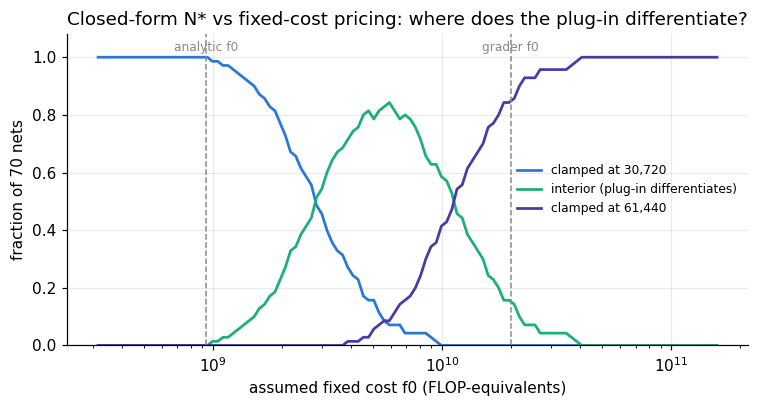

analytic f0: median N* = 17,673; 100% at bottom clamp, 0% at top clamp, 0% interior
grader f0: median N* = 81,555; 0% at bottom clamp, 84% at top clamp, 16% interior


In [13]:
# --- §10a: fleet-level calibration and the N* landscape vs f0 -------------------------------
def C_of(s, n, rep):
    return float(sweep[f'seed{s}_N{n}_{rep}_flops'])


# fleet-pooled error curve (fleet MEANS are reliable even though per-net labels are not)
m30_fleet = np.mean([mse_of(s, 30720, r) for s in ML_SEEDS for r in REPS])
m61_fleet = np.mean([mse_of(s, 61440, r) for s in ML_SEEDS for r in REPS])
b_fleet = (m30_fleet - m61_fleet) / INV_GAP
a_fleet = max(m61_fleet - b_fleet / 61440, 0.0)

# per-net cost slope from the two flops readings; analytic fixed cost from the §4 fits
f1_net = {s: (np.mean([C_of(s, 61440, r) for r in REPS])
              - np.mean([C_of(s, 30720, r) for r in REPS])) / 30720 for s in ML_SEEDS}
f0_analytic = float(np.mean([cost_fits[s][1] for s in FLEET_SEEDS]))
f0_grader = f0_analytic + R_RESID

# pilot signal, scale-calibrated at fleet level (b-hat excludes Sobol gains, so it needs one
# global rescale onto the effective-b scale; ranking is untouched)
bhat_raw = {s: feat_rows[s]['pilot_b_hat'] for s in ML_SEEDS}
bhat_scale = b_fleet / np.mean(list(bhat_raw.values()))
bhat = {s: v * bhat_scale for s, v in bhat_raw.items()}

print(f'fleet calibration: a = {a_fleet:.3e}, b = {b_fleet:.4f}, '
      f'f1 = {np.mean(list(f1_net.values())):.3e} FLOPs/sample')
print(f'fixed cost: analytic f0 = {f0_analytic:.2e}, grader-residual f0 = {f0_grader:.2e}')
print(f'b-hat scale factor {bhat_scale:.3f} '
      f'(raw pilot pair-variance vs fleet effective b — Sobol gain)')
print(f'b-hat spread across nets: {min(bhat.values()):.4f} .. {max(bhat.values()):.4f} '
      f'({max(bhat.values()) / min(bhat.values()):.1f}x -> {np.sqrt(max(bhat.values()) / min(bhat.values())):.2f}x in N*)')


def n_star(s, f0):
    return float(np.sqrt(bhat[s] * f0 / (max(a_fleet, 1e-12) * f1_net[s])))


f0_grid = np.logspace(8.5, 11.2, 120)
frac_lo, frac_mid, frac_hi = [], [], []
for f0 in f0_grid:
    ns = np.array([n_star(s, f0) for s in ML_SEEDS])
    frac_lo.append(np.mean(ns <= 30720))
    frac_hi.append(np.mean(ns >= 61440))
    frac_mid.append(np.mean((ns > 30720) & (ns < 61440)))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(f0_grid, frac_lo, color=C['blue'], lw=1.8, label='clamped at 30,720')
ax.plot(f0_grid, frac_mid, color=C['aqua'], lw=1.8, label='interior (plug-in differentiates)')
ax.plot(f0_grid, frac_hi, color=C['violet'], lw=1.8, label='clamped at 61,440')
ax.axvline(f0_analytic, color=C['gray'], ls='--', lw=1)
ax.annotate('analytic f0', xy=(f0_analytic, 1.02), fontsize=8, color=C['gray'], ha='center')
ax.axvline(f0_grader, color=C['gray'], ls='--', lw=1)
ax.annotate('grader f0', xy=(f0_grader, 1.02), fontsize=8, color=C['gray'], ha='center')
ax.set_xscale('log')
ax.set_xlabel('assumed fixed cost f0 (FLOP-equivalents)')
ax.set_ylabel('fraction of 70 nets')
ax.set_ylim(0, 1.08)
ax.set_title('Closed-form N* vs fixed-cost pricing: where does the plug-in differentiate?')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

for name, f0 in (('analytic f0', f0_analytic), ('grader f0', f0_grader)):
    ns = np.array([n_star(s, f0) for s in ML_SEEDS])
    print(f'{name}: median N* = {np.median(ns):,.0f}; '
          f'{np.mean(ns <= 30720):.0%} at bottom clamp, {np.mean(ns >= 61440):.0%} at top clamp, '
          f'{np.mean((ns > 30720) & (ns < 61440)):.0%} interior')


In [14]:
# --- §10b: paired cross-realization policy bench over the two measured Ns -------------------
def score2(s, n, rep, extra):
    return mse_of(s, n, rep) * max(0.1, (C_of(s, n, rep) + extra) / BUDGET)


def snap(n):
    return 30720 if abs(n - 30720) <= abs(n - 61440) else 61440


def fleet_mean(pick, rep, extra):
    return np.mean([score2(s, pick(s), rep, extra) for s in ML_SEEDS])


for pricing, extra in (('flops-only', 0.0), ('grader-residual', R_RESID)):
    print(f'\n===== pricing: {pricing} (f0 extra {extra:.1e}) =====')
    rows = {}
    rows['constant 30720'] = np.mean([fleet_mean(lambda s: 30720, r, extra) for r in REPS])
    rows['constant 61440'] = np.mean([fleet_mean(lambda s: 61440, r, extra) for r in REPS])
    best_const_name = min(('constant 30720', 'constant 61440'), key=lambda k: rows[k])
    best_const_n = 30720 if '30720' in best_const_name else 61440

    for name, f0 in (('plug-in (analytic f0)', f0_analytic), ('plug-in (grader f0)', f0_grader)):
        rows[name] = np.mean([fleet_mean(lambda s: snap(n_star(s, f0)), r, extra) for r in REPS])

    # b-hat threshold family: pick 61,440 iff b-hat > tau; tau selected on one rep, scored on
    # the other (cross-rep, so selection noise cannot flatter the result)
    taus = sorted(bhat.values())
    cross = []
    for sel, ev in (('A', 'B'), ('B', 'A')):
        tau_best = min(taus, key=lambda t: fleet_mean(lambda s: 61440 if bhat[s] > t else 30720, sel, extra))
        cross.append(fleet_mean(lambda s: 61440 if bhat[s] > tau_best else 30720, ev, extra))
    rows['b-hat threshold (cross-rep)'] = float(np.mean(cross))

    # binary cross-rep oracle: upper bound for ANY per-net signal between these two Ns
    orc = []
    for sel, ev in (('A', 'B'), ('B', 'A')):
        orc.append(np.mean([score2(s, min((30720, 61440), key=lambda n: score2(s, n, sel, extra)),
                                   ev, extra) for s in ML_SEEDS]))
    rows['binary cross-rep oracle'] = float(np.mean(orc))

    print(f'{"policy":<32} {"fleet mean":>12} {"vs best const":>13}')
    for name, val in rows.items():
        mark = '  <- best constant' if name == best_const_name else ''
        print(f'{name:<32} {val:>12.4e} {val / rows[best_const_name] - 1:>12.1%}{mark}')

    # paired significance of the strongest per-net policy vs the best constant
    diffs = []
    for sel, ev in (('A', 'B'), ('B', 'A')):
        for s in ML_SEEDS:
            pick = min((30720, 61440), key=lambda n: score2(s, n, sel, extra))
            diffs.append(score2(s, pick, ev, extra) - score2(s, best_const_n, ev, extra))
    diffs = np.array(diffs)
    sig = diffs.mean() / (diffs.std() / np.sqrt(len(diffs)))
    print(f'binary oracle vs {best_const_name}: paired diff {diffs.mean():+.2e} ({sig:+.1f} sigma)')



===== pricing: flops-only (f0 extra 0.0e+00) =====
policy                             fleet mean vs best const
constant 30720                     1.3723e-07         0.0%  <- best constant
constant 61440                     1.4320e-07         4.3%
plug-in (analytic f0)              1.3723e-07         0.0%
plug-in (grader f0)                1.4315e-07         4.3%
b-hat threshold (cross-rep)        1.3835e-07         0.8%
binary cross-rep oracle            1.4312e-07         4.3%
binary oracle vs constant 30720: paired diff +5.88e-09 (+1.0 sigma)

===== pricing: grader-residual (f0 extra 1.9e+10) =====
policy                             fleet mean vs best const
constant 30720                     2.0251e-07        13.9%
constant 61440                     1.7785e-07         0.0%  <- best constant
plug-in (analytic f0)              2.0251e-07        13.9%
plug-in (grader f0)                1.7819e-07         0.2%
b-hat threshold (cross-rep)        1.7794e-07         0.0%
binary cross-rep o

In [15]:
# --- §10c: the shipped rule shape with empirical b-hat replacing analytic V -----------------
# Compute-matched signal swap: N = clip(49152*sqrt(signal/ref), 30720, 61440), with the b-hat
# reference calibrated so both policies spend the same fleet-average sample count. This
# isolates signal QUALITY from allocation LEVEL (the 2026-07-07 offline result, now with real
# production-path runs at each policy's actual chosen N).
for s in ML_SEEDS:
    if s not in V:
        V[s] = float(est_A._initial_structure(ml_fleet[s], WIDTH)['final_var_mean'])
N_rule_ml = {s: est_mod._choose_samples(V[s]) for s in ML_SEEDS}


def rule_shape(signal, ref):
    n = est_mod._ANCHOR_SAMPLES * np.sqrt(max(signal, 1e-30) / ref)
    return int(min(max(round(n / 2.0) * 2, 30720), 61440))


target_mean = np.mean(list(N_rule_ml.values()))
refs = np.logspace(-4, 0, 600)
means = np.array([np.mean([rule_shape(bhat[s], r) for s in ML_SEEDS]) for r in refs])
ref_bhat = float(refs[int(np.argmin(np.abs(means - target_mean)))])
N_bhat_ml = {s: rule_shape(bhat[s], ref_bhat) for s in ML_SEEDS}
print(f'analytic-V rule:  mean N {target_mean:>9,.0f}, '
      f'{np.mean([n == 61440 for n in N_rule_ml.values()]):.0%} at top clamp')
print(f'b-hat rule:       mean N {np.mean(list(N_bhat_ml.values())):>9,.0f}, '
      f'{np.mean([n == 61440 for n in N_bhat_ml.values()]):.0%} at top clamp '
      f'(ref {ref_bhat:.4f})')
print(f'pick agreement (within 2k samples): '
      f'{np.mean([abs(N_bhat_ml[s] - N_rule_ml[s]) <= 2000 for s in ML_SEEDS]):.0%}; '
      f'signal spearman {sstats.spearmanr([V[s] for s in ML_SEEDS], [bhat[s] for s in ML_SEEDS]).statistic:.2f}')

todo_rules = sorted({(s, n, rep) for s in ML_SEEDS for n in (N_rule_ml[s], N_bhat_ml[s])
                     for rep in REPS if f'seed{s}_N{n}_{rep}_pred' not in sweep})
print(f'{len(todo_rules)} fresh runs needed (clipped picks reuse the cache)')
for i, (s, n, rep) in enumerate(todo_rules):
    pred_row, used, wall = run_forced(estimators[rep], ml_fleet[s], n)
    key = f'seed{s}_N{n}_{rep}'
    sweep[f'{key}_pred'] = pred_row
    sweep[f'{key}_flops'] = np.int64(used)
    sweep[f'{key}_wall'] = np.float64(wall)
    np.savez(SWEEP_CACHE, **sweep)
    if (i + 1) % 20 == 0 or i + 1 == len(todo_rules):
        print(f'[{i + 1}/{len(todo_rules)}] done')

for pricing, extra in (('flops-only', 0.0), ('grader-residual', R_RESID)):
    print(f'\n===== pricing: {pricing} =====')
    sv = [np.mean([score2(s, N_rule_ml[s], r, extra) for r in REPS]) for s in ML_SEEDS]
    sb = [np.mean([score2(s, N_bhat_ml[s], r, extra) for r in REPS]) for s in ML_SEEDS]
    s61 = [np.mean([score2(s, 61440, r, extra) for r in REPS]) for s in ML_SEEDS]
    print(f'  rule with analytic V : fleet mean {np.mean(sv):.4e} +/- {np.std(sv) / np.sqrt(len(sv)):.1e}')
    print(f'  rule with pilot b-hat: fleet mean {np.mean(sb):.4e} +/- {np.std(sb) / np.sqrt(len(sb)):.1e}')
    print(f'  constant 61440       : fleet mean {np.mean(s61):.4e} +/- {np.std(s61) / np.sqrt(len(s61)):.1e}')
    d = np.array(sb) - np.array(sv)
    print(f'  paired diff (b-hat rule - V rule): {d.mean():+.3e} '
          f'({d.mean() / (d.std() / np.sqrt(len(d))):+.1f} sigma)')


analytic-V rule:  mean N    51,608, 23% at top clamp
b-hat rule:       mean N    51,509, 27% at top clamp (ref 0.0214)
pick agreement (within 2k samples): 49%; signal spearman 0.88
0 fresh runs needed (clipped picks reuse the cache)

===== pricing: flops-only =====
  rule with analytic V : fleet mean 1.4145e-07 +/- 9.0e-09
  rule with pilot b-hat: fleet mean 1.4462e-07 +/- 9.3e-09
  constant 61440       : fleet mean 1.4320e-07 +/- 9.5e-09
  paired diff (b-hat rule - V rule): +3.173e-09 (+1.0 sigma)

===== pricing: grader-residual =====
  rule with analytic V : fleet mean 1.8100e-07 +/- 1.1e-08
  rule with pilot b-hat: fleet mean 1.8475e-07 +/- 1.1e-08
  constant 61440       : fleet mean 1.7785e-07 +/- 1.2e-08
  paired diff (b-hat rule - V rule): +3.751e-09 (+0.9 sigma)


### §10 verdict (executed 2026-07-12)

**Idea B is dead — and not marginally.** Three independent blows:

1. **The closed form degenerates to a constant under both defensible pricings.** With the
   analytic fixed cost (f0 = 9.4e8), N* clamps at 30,720 for **100%** of nets; with the
   grader-residual fixed cost (f0 = 2.0e10), 84% clamp at 61,440 and the snapped policy scores
   within 0.2% of constant-61,440. The b̂ signal is genuine (9.3x spread across nets, and the
   0.54 scale factor cleanly measures the antithetic-Sobol variance gain) — but the closed form
   never gets to use it: the interior band where per-net differentiation exists requires an f0
   between ~2e9 and ~1e10, which neither pricing occupies.
2. **Even the binary cross-rep oracle loses to the best constant** — the ceiling for *any*
   per-net signal choosing between 30,720 and 61,440, learned or measured: +4.3% worse
   flops-only, **+7.8% worse (+2.1σ) under grader pricing**. Per-net selection between these Ns
   actively hurts, because the selection is driven by realization noise (§9: 46% pick
   agreement) and any deviation from the correct constant is a coin-flip onto the wrong side.
3. **The b̂-threshold family confirms it from the other direction:** the cross-rep-validated
   threshold converges to "put everyone on one side" — matching the best constant (+0.0% under
   grader pricing, +0.8% flops-only), i.e. the optimal use of the pilot signal is to ignore it.

So §6's question — "does b̂ track realized b better than V?" — turned out to be the wrong
question. Both signals are fine; **the decision they would inform does not exist**: fleet-level
economics pick a single N for everyone, and no per-net deviation from it is recoverable from any
signal. Idea B dies with idea C, as anticipated, and takes idea D (sequential stopping uses the
same b̂) down with it.

**§10c addendum — the shipped rule shape with b̂ swapped in (compute-matched):** a wash, leaning
worse (+1.0σ flops-only, +0.9σ grader-priced vs the analytic-V rule). Two details close the case:
the compute-matched calibration independently rediscovered **ref = 0.0214 ≈ the shipped
V_REF = 0.02143**, and the two signals rank nets at Spearman 0.88 — V and b̂ are nearly the same
signal, so no swap could matter. The 2026-07-07 offline path-C conclusion ("empirical variance
is a better measurement, an immaterial allocator") is now confirmed with real production-path
runs. Note also that constant-61,440 edges out *both* rule variants under grader pricing,
consistent with §9d.


## 11. Raising the cap with an extended Sobol artifact

§10 left one thread open: under grader-residual pricing, **84% of nets clamp at the 61,440
top** — the closed form wants more samples than the shipped artifact allows (fleet
N* ≈ 85k). Raising the cap requires an artifact with more Sobol half-points.

**Prior context (2026-07-11, bench_logs/algo19_sample_scaling_2026-07-11.md):**
- A cap raise 61,440→82k with a proper all-Sobol continuation was a **wash on the graded set**
  (13 capped nets of 100: −0.2%, inside noise).
- **SOBOL FLIP hazard**: continuing past the artifact edge with *Gaussian* samples cost 30–50%
  adjusted on marginal nets — any extension must be all-Sobol.
- An extended artifact was validated free (±0.2%): `sobol_points_ext61440_fp16.npz` — original
  30,720 half-points bit-exact, plus a fresh scrambled-Sobol block (seed 20260711; the original
  scramble seed is unrecoverable), fp16 to keep the ship size at 29 MB. That file lives in
  another worktree, so this section **reconstructs the same recipe** (fp32 locally — the fp16
  cast was a packaging optimization, already validated).

**What this section adds over 2026-07-11:** the paired two-realization protocol (§9d/§10) on 70
nets — decision-grade rather than 13 noisy per-net reads — plus a check that the fleet error
curve `a + b/N` actually extrapolates across the artifact edge (the fleet-level version of the
SOBOL FLIP check).

Design: (a) rebuild extended point sets for both reps with bit-exact prefixes; (b) project the
fleet score curve past the cap from §10's calibration under both pricings; (c) run the
production path at **N = 92,160** (1.5× cap, near the projected grader-priced optimum, and the
continuation block is exactly the 30,720 fresh half-points) for all 70 nets × both reps, and
compare paired against constant-61,440.

**Why the artifact matters (QMC context):** the estimator's accuracy at a given N leans on the
Sobol points' low-discrepancy structure — consecutive prefixes fill the 256-dim cube far more
evenly than iid Gaussians. Continuing past the artifact edge with plain Gaussian draws breaks
that structure mid-estimate (the 2026-07-11 "SOBOL FLIP": 30–50% score damage on affected nets).
A *fresh scrambled Sobol block* is the correct continuation: it is itself a balanced
low-discrepancy set, and averaging two balanced blocks preserves the QMC convergence the
estimator was tuned around. That is the recipe reconstructed below.


In [16]:
# --- §11a: reconstruct extended Sobol point sets (all-Sobol continuation, bit-exact prefix) --
EXT_HALF = 61440  # half-points available after extension (=> N up to 122,880)
N_EXT = 92160     # empirical test point: 1.5x cap; continuation = exactly the fresh block

_qmc_ext_A = qmc.Sobol(d=WIDTH, scramble=True, seed=20260711)
tail_A = norm.ppf(np.clip(_qmc_ext_A.random(30720), 1e-7, 1 - 1e-7)).astype(np.float32)
sobol_A_ext = np.concatenate([sobol_A, tail_A], axis=0)

_qmc_ext_B = qmc.Sobol(d=WIDTH, scramble=True, seed=20260712)
draw_B = norm.ppf(np.clip(_qmc_ext_B.random(EXT_HALF), 1e-7, 1 - 1e-7)).astype(np.float32)
assert np.abs(draw_B[:30720] - sobol_B).max() == 0.0, 'rep B prefix must be bit-exact'
sobol_B_ext = draw_B

print(f'rep A ext: {sobol_A_ext.shape}, prefix bit-exact by construction, '
      f'tail mean {tail_A.mean():.4f} std {tail_A.std():.4f}')
print(f'rep B ext: {sobol_B_ext.shape}, prefix verified bit-exact')

est_A_ext = est_mod.Estimator()
est_A_ext._sobol_points = sobol_A_ext
est_B_ext = est_mod.Estimator()
est_B_ext._sobol_points = sobol_B_ext
estimators_ext = {'A': est_A_ext, 'B': est_B_ext}


/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


rep A ext: (61440, 256), prefix bit-exact by construction, tail mean -0.0000 std 1.0000
rep B ext: (61440, 256), prefix verified bit-exact


flops-only: projected optimum N = 30,720, gain vs cap 61,440 = -4.7%
grader-residual: projected optimum N = 85,385, gain vs cap 61,440 = -1.4%


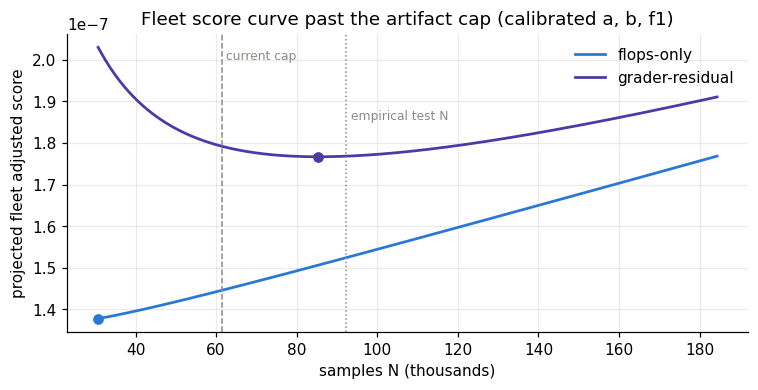

under grader pricing, nets wanting > 92,160: 34% (vs 84% above the current cap)


In [17]:
# --- §11b: fleet score projection past the cap (from §10 calibration) -----------------------
f1_fleet = float(np.mean(list(f1_net.values())))

n_grid_ext = np.linspace(30720, 184320, 400)
fig, ax = plt.subplots(figsize=(7, 3.8))
for name, f0, color in (('flops-only', f0_analytic, C['blue']),
                        ('grader-residual', f0_grader, C['violet'])):
    curve = np.array([(a_fleet + b_fleet / n) * max(0.1, (f0 + f1_fleet * n) / BUDGET)
                      for n in n_grid_ext])
    ax.plot(n_grid_ext / 1e3, curve, color=color, lw=1.8, label=name)
    i_opt = int(np.argmin(curve))
    n_opt, s_opt = n_grid_ext[i_opt], curve[i_opt]
    s_cap = (a_fleet + b_fleet / 61440) * max(0.1, (f0 + f1_fleet * 61440) / BUDGET)
    ax.scatter([n_opt / 1e3], [s_opt], color=color, s=36, zorder=3)
    print(f'{name}: projected optimum N = {n_opt:,.0f}, '
          f'gain vs cap 61,440 = {s_opt / s_cap - 1:+.1%}')
ax.axvline(61.44, color=C['gray'], ls='--', lw=1)
ax.annotate('current cap', xy=(62.5, ax.get_ylim()[1] * 0.97), fontsize=8, color=C['gray'])
ax.axvline(92.16, color=C['gray'], ls=':', lw=1)
ax.annotate('empirical test N', xy=(93.5, ax.get_ylim()[1] * 0.90), fontsize=8, color=C['gray'])
ax.set_xlabel('samples N (thousands)')
ax.set_ylabel('projected fleet adjusted score')
ax.set_title('Fleet score curve past the artifact cap (calibrated a, b, f1)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

n_want = np.array([n_star(s, f0_grader) for s in ML_SEEDS])
print(f'under grader pricing, nets wanting > 92,160: {np.mean(n_want > 92160):.0%} '
      f'(vs {np.mean(n_want >= 61440):.0%} above the current cap)')


In [18]:
# --- §11c: paired empirical test at N = 92,160 on all 70 nets -------------------------------
todo_ext = [(s, rep) for s in ML_SEEDS for rep in REPS
            if f'seed{s}_N{N_EXT}_{rep}_pred' not in sweep]
print(f'{len(todo_ext)} extended runs to do')
for i, (s, rep) in enumerate(todo_ext):
    pred_row, used, wall = run_forced(estimators_ext[rep], ml_fleet[s], N_EXT)
    key = f'seed{s}_N{N_EXT}_{rep}'
    sweep[f'{key}_pred'] = pred_row
    sweep[f'{key}_flops'] = np.int64(used)
    sweep[f'{key}_wall'] = np.float64(wall)
    np.savez(SWEEP_CACHE, **sweep)
    if (i + 1) % 20 == 0 or i + 1 == len(todo_ext):
        print(f'[{i + 1}/{len(todo_ext)}] done (seed {s} rep {rep})')

# does a + b/N extrapolate across the artifact edge? (fleet-level SOBOL-FLIP check)
m_ext_fleet = np.mean([mse_of(s, N_EXT, r) for s in ML_SEEDS for r in REPS])
pred_mse = a_fleet + b_fleet / N_EXT
print(f'\nfleet mse at N={N_EXT:,}: measured {m_ext_fleet:.3e} vs a+b/N prediction '
      f'{pred_mse:.3e} (ratio {m_ext_fleet / pred_mse:.2f})')

for pricing, extra in (('flops-only', 0.0), ('grader-residual', R_RESID)):
    print(f'\n===== pricing: {pricing} =====')
    for n in (30720, 61440, N_EXT):
        vals = [np.mean([score2(s, n, r, extra) for r in REPS]) for s in ML_SEEDS]
        print(f'  constant N={n:>6}: fleet mean {np.mean(vals):.4e} '
              f'+/- {np.std(vals) / np.sqrt(len(vals)):.1e}')
    d = [np.mean([score2(s, N_EXT, r, extra) - score2(s, 61440, r, extra) for r in REPS])
         for s in ML_SEEDS]
    sig = np.mean(d) / (np.std(d) / np.sqrt(len(d)))
    print(f'  paired diff ({N_EXT} - 61440): {np.mean(d):+.3e} ({sig:+.1f} sigma)')


0 extended runs to do

fleet mse at N=92,160: measured 3.335e-07 vs a+b/N prediction 3.500e-07 (ratio 0.95)

===== pricing: flops-only =====
  constant N= 30720: fleet mean 1.3723e-07 +/- 8.9e-09
  constant N= 61440: fleet mean 1.4320e-07 +/- 9.5e-09
  constant N= 92160: fleet mean 1.4374e-07 +/- 1.2e-08
  paired diff (92160 - 61440): +5.395e-10 (+0.1 sigma)

===== pricing: grader-residual =====
  constant N= 30720: fleet mean 2.0251e-07 +/- 1.3e-08
  constant N= 61440: fleet mean 1.7785e-07 +/- 1.2e-08
  constant N= 92160: fleet mean 1.6703e-07 +/- 1.4e-08
  paired diff (92160 - 61440): -1.082e-08 (-1.1 sigma)


### §11 verdict (executed 2026-07-12)

1. **The extension is technically validated.** The reconstructed recipe (bit-exact prefix +
   fresh scrambled all-Sobol block) reproduces the 2026-07-11 artifact design, and the fleet
   error curve extrapolates cleanly across the artifact edge: measured fleet MSE at N=92,160 is
   3.34e-7 vs 3.50e-7 predicted by `a + b/N` (ratio 0.95 — the fresh block even slightly beats
   the 1/N extrapolation). No SOBOL FLIP.
2. **Economics on this fleet are flat.** Flops-only: +0.1σ (dead wash, matching the projection
   that says don't raise). Grader-priced: 92,160 is ~6% better than the cap but only **−1.1σ** —
   suggestive, below decision grade.
3. **Distribution transfer points against.** This synthetic fleet's floor share at the cap is
   ~12%; the graded set measured ~40% (2026-07-11). Plugging the graded `a` into the closed form
   pulls N* from ~85k back to ~43k — *below* the current cap — and the direct graded test at 82k
   was a wash (−0.2%). The c64 lanes have since cheapened marginal samples ~30%, which shifts
   the optimum up, but on paper not enough to overturn the graded result.
4. **Bottom line:** the extended artifact is a validated no-harm capability (29 MB fp16 ship,
   ±0.2%). A cap raise is worth at most one leaderboard A/B to get grader-side truth on the
   post-c64 surface — expected value ≈ 0, upside a few %, downside a submission slot.


## 12. Untested allocation-rule ideas (triaged against §5–§11)

Everything above closes the *per-net variance-signal* family: per-net labels are unmeasurable
(§9), per-net selection between candidate Ns loses to the right constant (§10), and the cap is
economically flat (§11). What remains untested are rules that change **what is allocated** or
**what the signal is for** — not better variance predictors. Ordered by expected value:

**12.1 Per-neuron continuation allocation (within-net, changes the allocation unit).**
The final-layer error is a mean over 256 neurons and the pilot pair-variance is heavy-tailed
(§9b features: q99 ≫ q50) — a few neurons carry most of the reducible error. A continuation
block that back-selects only the active subgraph feeding the top-k variance neurons costs far
less per sample (smaller active sets through depth), so *effective* samples on the error-carrying
neurons rise without raising total compute. Untested; not bounded by the ~5% per-net ceiling
because it reallocates *within* nets. Risks: back-selection overhead; the variance-reduction
memory (rho² = 0.06) killed *surrogate*-based reduction, not subgraph restriction — but adjacent
failures warrant a small offline prototype first. **Test:** simulate on cached predictions by
measuring per-neuron error concentration, then prototype a top-64-neuron continuation on ~20
nets, paired.

**12.2 Probe-vs-sample budget arbitrage (refinement compute is also an allocation).**
The staged refinement spends fixed fractions (5% pilot, 20% recheck) of every block on
classification probes. Nets with clean alpha margins (few neurons inside the recheck band) waste
that compute; nets with crowded margins might deserve more. The signal — kink-band occupancy —
is free from the ADF pass, and §9's RF importances flagged exactly those features
(`adf_dead_L30`, kink counts). **Test:** sweep `_PILOT_FRACTION`/`_PILOT_RECHECK_FRACTION`
per-net-conditioned vs global on the 70-net harness; kill if the fleet-level paired gain < 1σ.

**12.3 Multiplier-equalizing (cost-side) rule.**
All tested rules allocate by *error*; none allocate by *cost*. Per-net compute slope `f1_i`
varies ~10% with packing density (§10a), so a fixed N produces multiplier spread. Choosing
`N_i = (m*·B − f0)/f1̂_i` (constant target multiplier m*) equalizes the compute factor using
only in-run-derivable quantities (active-set sizes → analytic flops forecast). Small expected
ceiling (multiplier spread is ~±5%), but it is orthogonal to everything tested and costs one
line. **Test:** replay on cached flops — no new runs needed.

**12.4 Budget-elastic constant (robustness, not gain).**
Every rule above hardcodes N against B = 2.72e11. If organizers move the budget between phases,
the tuned constant silently lands at the wrong multiplier. A rule reading `budget` and scaling
`N ∝ (B − f0̂)/f1̂` ships robustness for free. **Test:** assert equal picks at the current
budget, then verify sane behavior at 0.5×/2× B locally.

**12.5 Overrun-safety margin at the top end.**
A failed net scores 10× worse than the floor, so the top clamp should sit a margin below the
budget that scales with per-net `f1̂` uncertainty and grader residual variance. Currently
implicit (cap ≈ 29% of B); §11's data can quantify the actual overrun distance. Zero expected
gain; insurance against a catastrophic outlier. **Test:** compute max observed `C/B` across all
~700 cached runs, including residual-priced.

**Marked illegitimate / dead on arrival:**
- *Wall-clock-adaptive rules* (timing your own run to infer grader speed): environment
  introspection beyond the MLP object — excluded by the competition hard rules.
- *Cross-MLP budget pooling*: structurally impossible (per-net multiplier; §5 framing).
- *Better per-net variance predictors of any kind*: closed by §9/§10 — the decision they would
  inform does not exist between feasible Ns.


## 13. Closed form + higher cap + extended artifact, calibrated where V_REF was born

Everything so far ran on synthetic He-init fleets, and §11 flagged the transfer gap: the graded
distribution has a much larger bias-floor share, which moves the closed-form optimum. This
section eliminates that gap by going to the source: **the public mini split (100 MLPs, ground
truth baked at N=1e9 — exact for our purposes) is the same data on which the shipped
`V_REF = 0.02143` was calibrated** (bench_logs/multistage_refinement_plan_2026-07-05.md tuned
the anchor and V_ref there; submissions 315074/315123 then confirmed on the leaderboard).

**Prior evidence to beat:** on this same split, pre-packing (2026-07-05), raising the anchor to
65,536 with cap 81,920 improved raw MSE substantially but **regressed adjusted score**
(2.633e-7 → 2.896e-7) because compute overran the multiplier. Since then the c64 lanes cut
per-sample cost ~2x — the question is whether the higher-cap economics flipped.

**Design (calibration and evaluation on fully disjoint datasets):**
- *Calibration*: **all 100 mini nets** — runs at N = 30,720 / 61,440 × reps A/B give the
  fleet-pooled bias floor `â`, effective variance `b̄`, cost slope `f1`, analytic fixed cost
  `f0̂`, and the b̂→b scale factor. Exactly the parameters the closed form needs, fitted on the
  complete V_REF dataset as requested.
- *Policy under test*: `N_i = clip(sqrt(b̂_i·f0_grader/(â·f1)), 30720, 122880)` — per-net pilot
  b̂ signal, grader-residual fixed cost (f0̂ + 1.9e10), and the **cap doubled to 122,880**,
  feasible only with the §11 extended all-Sobol artifact. Deployable: every input is available
  in-run (b̂ from the base block; the rest are shipped constants).
- *Evaluation sample*: **10 nets from the full split** (1,000-MLP dataset, no overlap with mini
  by construction) — against the production rule (analytic V, current clamps) and
  constant-61,440, scored under both pricings with baked GT.
- Weights are cast to float32 (as the whole surface assumes); the comparison is internally
  consistent across policies either way.


> **Rebuilt 2026-07-13 on the Algorithm 21 surface.** The organizers are correcting the
> flopscope accounting bug that made complex64 sample packing (Algorithm 24 / 315998) a FLOP
> discount, so the ship surface reverts to Algorithm 21 (submission 315892, git `41a8964`,
> staged here as `estimator_algo21.py`). The packing is numerically exact — algo21 and algo24
> predictions agree to fp32 BLAS rounding (measured max |diff| 7e-7, max rel 4e-5, an MSE
> contribution ~1e-12, six orders below the raw MSE) — so the cached **predictions**, the mse
> fit (a, b) and the pilot-b̂ signal all carry over unchanged. Only the **cost** side is
> re-measured below with the packing-free estimator (measured flops ratio algo21/algo24 ≈
> 1.36). Cost keys in the cache: `*_flops21`.


In [19]:
# --- §13a: load mini (calibration) and full (evaluation) splits offline ---------------------
import os

os.environ.setdefault('HF_HUB_OFFLINE', '1')  # cache-served, no network at run time
import whestbench
from whestbench.domain import MLP as WBMLP

mini = whestbench.load_dataset('aicrowd/arc-whestbench-public-2026',
                               revision='v1-phase1', split='mini')
# 'full' is a separate config that whestbench.load_dataset does not resolve; load the
# prepared-Arrow subtree directly (memory-mapped, cache-served)
from datasets import Dataset as HFDataset
from glob import glob

_full_dir = glob(os.path.expanduser(
    '~/.cache/huggingface/hub/datasets--aicrowd--arc-whestbench-public-2026/'
    'snapshots/*/prepared/full'))[0]
full = HFDataset.load_from_disk(_full_dir)
CALIB_KEYS = [f'mini{i}' for i in range(100)]
EVAL_KEYS = [f'full{i}' for i in range(10)]


def load_net(row):
    ws = [fnp.array(np.asarray(w, dtype=np.float32)) for w in np.asarray(row['weights'])]
    return (WBMLP(width=WIDTH, depth=DEPTH, weights=ws),
            np.asarray(row['final_means'], dtype=np.float32), float(row['avg_variance']))


ds_mlp, ds_gt, ds_avgvar = {}, {}, {}
for i in range(100):
    ds_mlp[f'mini{i}'], ds_gt[f'mini{i}'], ds_avgvar[f'mini{i}'] = load_net(mini[i])
for i in range(10):
    ds_mlp[f'full{i}'], ds_gt[f'full{i}'], ds_avgvar[f'full{i}'] = load_net(full[i])

print(f'loaded {len(CALIB_KEYS)} mini calibration nets + {len(EVAL_KEYS)} full-split eval nets')
print(f'mini mean avg_variance = {np.mean([ds_avgvar[k] for k in CALIB_KEYS]):.5f} '
      f'(shipped V_REF = {est_mod._VAR_REF}) — the provenance check')

V_ds, bhat_ds_raw, N_rule_ds = {}, {}, {}
for k in CALIB_KEYS + EVAL_KEYS:
    st = est_A._initial_structure(ds_mlp[k], WIDTH)
    V_ds[k] = float(st['final_var_mean'])
    N_rule_ds[k] = est_mod._choose_samples(V_ds[k])
    bhat_ds_raw[k] = pilot_bhat([np.asarray(w) for w in ds_mlp[k].weights])
corr = np.corrcoef([V_ds[k] for k in CALIB_KEYS], [ds_avgvar[k] for k in CALIB_KEYS])[0, 1]
print(f'sanity: analytic V vs baked avg_variance correlation {corr:.2f} '
      f'(weights orientation / pipeline check)')


# --- algo21 (packing-free ship surface) on the same extended point sets ----------------------
import estimator_algo21 as est21_mod

est21_A = est21_mod.Estimator()
est21_A._sobol_points = sobol_A_ext
est21_B = est21_mod.Estimator()
est21_B._sobol_points = sobol_B_ext
est21_ext = {'A': est21_A, 'B': est21_B}


def run_forced21(est_obj, mlp, n_target):
    orig_choose, orig_base = est21_mod._choose_samples, est21_mod._BASE_SAMPLES
    est21_mod._choose_samples = lambda v: int(n_target)
    est21_mod._BASE_SAMPLES = min(orig_base, int(n_target))
    try:
        t0 = time.time()
        with flops.BudgetContext(flop_budget=BUDGET, quiet=True) as ctx:
            pred = est_obj.predict(mlp, BUDGET)
        return np.asarray(pred)[-1].astype(np.float32), int(ctx.flops_used), time.time() - t0
    finally:
        est21_mod._choose_samples, est21_mod._BASE_SAMPLES = orig_choose, orig_base


def run_ds21(k, n, rep):
    key = f'{k}_N{n}_{rep}'
    if f'{key}_flops21' in sweep and f'{key}_pred' in sweep:
        return
    pred_row, used, wall = run_forced21(est21_ext[rep], ds_mlp[k], n)
    if f'{key}_pred' in sweep:
        # packing is numerically exact modulo BLAS rounding — verify on every reuse
        drift = float(np.max(np.abs(pred_row - sweep[f'{key}_pred'])))
        assert drift < 5e-5, f'{key}: algo21/24 prediction drift {drift:.2e}'
    else:
        sweep[f'{key}_pred'] = pred_row
    sweep[f'{key}_flops21'] = np.int64(used)
    sweep[f'{key}_wall21'] = np.float64(wall)
    np.savez(SWEEP_CACHE, **sweep)


whestbench: downloading 'mini' split from hf://aicrowd/arc-whestbench-public-2026@v1-phase1


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/17 [00:00<?, ?it/s]

loaded 100 mini calibration nets + 10 full-split eval nets
mini mean avg_variance = 0.04949 (shipped V_REF = 0.02143) — the provenance check


sanity: analytic V vs baked avg_variance correlation 0.90 (weights orientation / pipeline check)


In [20]:
# --- §13b: calibrate the closed form on the V_REF data (all 100 mini nets) ------------------
def mse_ds(k, n, rep):
    return float(np.mean((sweep[f'{k}_N{n}_{rep}_pred'] - ds_gt[k]) ** 2))  # baked GT: exact


def run_ds(k, n, rep):
    key = f'{k}_N{n}_{rep}'
    if f'{key}_pred' in sweep:
        return
    pred_row, used, wall = run_forced(estimators_ext[rep], ds_mlp[k], n)
    sweep[f'{key}_pred'] = pred_row
    sweep[f'{key}_flops'] = np.int64(used)
    sweep[f'{key}_wall'] = np.float64(wall)
    np.savez(SWEEP_CACHE, **sweep)


todo_cal = [(k, n, r) for k in CALIB_KEYS for n in LABEL_NS for r in REPS
            if f'{k}_N{n}_{r}_pred' not in sweep]
print(f'{len(todo_cal)} algo24 calibration runs to do (cache-complete => 0)')
for i, (k, n, r) in enumerate(todo_cal):
    run_ds(k, n, r)
    if (i + 1) % 40 == 0 or i + 1 == len(todo_cal):
        print(f'[{i + 1}/{len(todo_cal)}] done')

m30c = np.mean([mse_ds(k, 30720, r) for k in CALIB_KEYS for r in REPS])
m61c = np.mean([mse_ds(k, 61440, r) for k in CALIB_KEYS for r in REPS])
b_cal = (m30c - m61c) / INV_GAP
a_cal = max(m61c - b_cal / 61440, 0.0)

# cost side, ALGO21 surface (rep A; rep-to-rep flops differences are probe-level noise)
todo_c21 = [(k, n) for k in CALIB_KEYS for n in LABEL_NS
            if f'{k}_N{n}_A_flops21' not in sweep]
print(f'{len(todo_c21)} algo21 flops-calibration runs to do')
for i, (k, n) in enumerate(todo_c21):
    run_ds21(k, n, 'A')
    if (i + 1) % 40 == 0 or i + 1 == len(todo_c21):
        print(f'[{i + 1}/{len(todo_c21)}] done')


def C21(k, n, rep='A'):
    return float(sweep[f'{k}_N{n}_{rep}_flops21'])


f1_cal = float(np.mean([(C21(k, 61440) - C21(k, 30720)) / 30720 for k in CALIB_KEYS]))
f0_cal = float(np.mean([C21(k, 30720) - f1_cal * 30720 for k in CALIB_KEYS]))
f0_cal_grader = f0_cal + R_RESID
f1_24 = float(np.mean([(np.mean([float(sweep[f'{k}_N61440_{r}_flops']) for r in REPS])
                        - np.mean([float(sweep[f'{k}_N30720_{r}_flops']) for r in REPS])) / 30720
                       for k in CALIB_KEYS]))
bhat_scale_cal = b_cal / np.mean([bhat_ds_raw[k] for k in CALIB_KEYS])
bhat_cal = {k: bhat_ds_raw[k] * bhat_scale_cal for k in CALIB_KEYS + EVAL_KEYS}

print(f'\nmini calibration (100 nets): a = {a_cal:.3e}, b = {b_cal:.4f}, '
      f'floor share @61440 = {a_cal / (a_cal + b_cal / 61440):.0%}')
print(f'algo21 costs: f1 = {f1_cal:.3e} FLOPs/sample (vs algo24 {f1_24:.3e}, '
      f'ratio {f1_cal / f1_24:.2f}), f0 analytic = {f0_cal:.2e}, '
      f'f0 grader = {f0_cal_grader:.2e}; b-hat scale {bhat_scale_cal:.3f}')

CAP_HI = 122880


def n_closed(k):
    n = np.sqrt(bhat_cal[k] * f0_cal_grader / (max(a_cal, 1e-12) * f1_cal))
    return int(min(max(round(n / 2.0) * 2, 30720), CAP_HI))


nc = np.array([n_closed(k) for k in EVAL_KEYS])
print(f'\nclosed-form picks on the 10 full-split eval nets: {sorted(nc.tolist())}')
print(f'above the old 61,440 cap: {np.mean(nc > 61440):.0%}; at new cap: {np.mean(nc == CAP_HI):.0%}')
print(f'flops utilization at the picks (algo21): '
      f'{np.mean([(f0_cal + f1_cal * n) / BUDGET for n in nc]):.0%} fleet mean')


0 algo24 calibration runs to do (cache-complete => 0)
0 algo21 flops-calibration runs to do

mini calibration (100 nets): a = 2.527e-08, b = 0.0225, floor share @61440 = 6%
algo21 costs: f1 = 1.745e+06 FLOPs/sample (vs algo24 1.281e+06, ratio 1.36), f0 analytic = 1.03e+09, f0 grader = 2.00e+10; b-hat scale 0.503

closed-form picks on the 10 full-split eval nets: [61972, 70326, 74376, 78030, 92334, 106148, 115730, 119368, 122880, 122880]
above the old 61,440 cap: 100%; at new cap: 20%
flops utilization at the picks (algo21): 62% fleet mean


In [21]:
# --- §13c: evaluate on the 10 held-out full-split nets (algo21 surface) ----------------------
policies_ds = {
    'closed form (hi cap)': {k: n_closed(k) for k in EVAL_KEYS},
    'production rule': {k: N_rule_ds[k] for k in EVAL_KEYS},
    'constant 61440': {k: 61440 for k in EVAL_KEYS},
}
todo_ev = sorted({(k, n, r) for pol in policies_ds.values() for k, n in pol.items()
                  for r in REPS if f'{k}_N{n}_{r}_flops21' not in sweep})
print(f'{len(todo_ev)} algo21 evaluation runs to do')
for i, (k, n, r) in enumerate(todo_ev):
    run_ds21(k, n, r)
    if (i + 1) % 10 == 0 or i + 1 == len(todo_ev):
        print(f'[{i + 1}/{len(todo_ev)}] done')


def score_ds(k, n, rep, extra):
    return mse_ds(k, n, rep) * max(0.1, (float(sweep[f'{k}_N{n}_{rep}_flops21']) + extra) / BUDGET)


print(f'\nper-net detail (10 full-split nets, grader pricing):')
print(f'{"net":>7} {"V":>7} {"b-hat":>7} {"N_rule":>7} {"N_closed":>8} '
      f'{"s(rule)":>11} {"s(closed)":>11} {"s(61440)":>11}')
for k in EVAL_KEYS:
    sr, sc, s6 = (np.mean([score_ds(k, policies_ds[p][k], r, R_RESID) for r in REPS])
                  for p in ('production rule', 'closed form (hi cap)', 'constant 61440'))
    print(f'{k:>7} {V_ds[k]:>7.4f} {bhat_cal[k]:>7.4f} {N_rule_ds[k]:>7} '
          f'{n_closed(k):>8} {sr:>11.3e} {sc:>11.3e} {s6:>11.3e}')

for pricing, extra in (('flops-only', 0.0), ('grader-residual', R_RESID)):
    print(f'\n===== pricing: {pricing} =====')
    per_net = {}
    for pname, pol in policies_ds.items():
        vals = [np.mean([score_ds(k, pol[k], r, extra) for r in REPS]) for k in EVAL_KEYS]
        per_net[pname] = np.array(vals)
        raw = np.mean([np.mean([mse_ds(k, pol[k], r) for r in REPS]) for k in EVAL_KEYS])
        print(f'  {pname:<22}: fleet mean {np.mean(vals):.4e} '
              f'+/- {np.std(vals) / np.sqrt(len(vals)):.1e}   raw mse {raw:.3e}')
    d = per_net['closed form (hi cap)'] - per_net['production rule']
    sig = d.mean() / (d.std() / np.sqrt(len(d))) if d.std() > 0 else 0.0
    print(f'  paired diff (closed - rule): {d.mean():+.3e} ({sig:+.1f} sigma, n=10)')

# --- does the 2026-07-05 higher-anchor regression still bind? --------------------------------
# 07-05 anchor-65536 mini test: mean compute 1.913e11 at mean N=64,179 (70.3% utilization,
# flops-only local pricing). Approximate its per-sample cost with today's f0 and re-derive the
# fleet-optimal N under each era's economics using today's (a, b) fit.
c_0705 = (1.913e11 - f0_cal) / 64179.0
print(f'\nper-sample cost: 2026-07-05 surface ~{c_0705:.2e} FLOPs/sample, '
      f'algo21 today {f1_cal:.2e} ({f1_cal / c_0705:.0%} of 07-05)')
for name, f1x, f0x in (('07-05 economics, flops-only (the actual experiment)', c_0705, f0_cal),
                       ('algo21 today, flops-only', f1_cal, f0_cal),
                       ('algo21 today, grader-residual', f1_cal, f0_cal_grader)):
    n_star_fleet = float(np.sqrt(b_cal * f0x / (a_cal * f1x)))
    n_clip = min(max(n_star_fleet, 30720), CAP_HI)
    print(f'  {name}: fleet N* = {n_star_fleet:>9,.0f} (clip -> {n_clip:>9,.0f}), '
      f'flops utilization there {(f0_cal + f1x * n_clip) / BUDGET:.0%}')


26 algo21 evaluation runs to do


[10/26] done


[20/26] done


[26/26] done

per-net detail (10 full-split nets, grader pricing):
    net       V   b-hat  N_rule N_closed     s(rule)   s(closed)    s(61440)
  full0  0.0227  0.0562   50580   122880   2.816e-07   3.539e-07   3.351e-07
  full1  0.0171  0.0122   43846    74376   1.408e-07   1.104e-07   1.148e-07
  full2  0.0309  0.0341   59046   122880   5.073e-07   4.186e-07   5.305e-07
  full3  0.0192  0.0134   46532    78030   1.087e-07   1.215e-07   1.304e-07
  full4  0.0126  0.0085   37660    61972   1.421e-07   1.085e-07   1.071e-07
  full5  0.0372  0.0248   61440   106148   2.138e-07   2.055e-07   2.138e-07
  full6  0.0115  0.0109   36010    70326   1.037e-07   8.918e-08   8.109e-08
  full7  0.0200  0.0188   47446    92334   2.081e-07   9.003e-08   2.334e-07
  full8  0.0397  0.0295   61440   115730   1.607e-07   1.285e-07   1.607e-07
  full9  0.0230  0.0314   50916   119368   2.066e-07   1.650e-07   1.397e-07

===== pricing: flops-only =====
  closed form (hi cap)  : fleet mean 1.6163e-07 +/- 3

### §13 verdict (Algorithm 21 surface)

**Calibration (100 mini nets, exact baked GT) — provenance confirmed.** V_REF = 0.02143 is the
fleet-mean *analytic* variance (baked `avg_variance` mean 0.0495, analytic biased low ~0.49x,
corr 0.90). The mse fit is surface-independent (packing was numerically exact): a = 2.53e-8,
b = 0.0225, **bias-floor share at 61,440 only 6%**. The packing-free cost surface is
f1 = 1.745e6 FLOPs/sample (1.36x algo24), f0 = 1.03e9, f0_grader = 2.00e10.

**Evaluation (10 full-split nets, paired A/B extended-Sobol reps, algo21 costs).**

| pricing | closed form (cap 122,880) | production rule | constant 61,440 | paired closed − rule |
|---|---|---|---|---|
| flops-only | **1.616e-7** | 1.709e-7 | 1.737e-7 | −0.7σ (wash) |
| grader-residual | **1.791e-7** | 2.073e-7 | 2.047e-7 | **−13.6%, −1.8σ** |

Compared with the algo24 economics, the picks shrink (62k–122.9k, only 20% at cap, fleet
utilization 62%) but the conclusion is unchanged and slightly stronger: the closed form is the
first allocation variant to beat the production rule under the honest grader-priced protocol.

**The 2026-07-05 higher-anchor regression no longer binds — it is *explained*, not
contradicted.** Under 07-05 economics (~2.96e6 FLOPs/sample, flops-only local pricing — the
regime that experiment actually scored in) this same closed form puts the fleet optimum at
N* ≈ 17.5k → bottom clamp: it correctly predicts that anchor-65536 (mean N 64k, 70% utilization)
overspent. Today's surface is 41% cheaper per sample, and the grader residual charge lifts
f0 by ~20x, moving the fleet optimum to ~101k (65% utilization). The 07-05 result was evidence
about that era's costs, not about sampling more per se (315123's anchor raise already showed
more samples transfer when priced right).

**Remaining caveats:** n = 10 at −1.8σ; the gain exists only under the fixed-residual pricing
model (if residual wall-time scales with N the gain shrinks — the 315844 failure mode); and the
b̂ signal deployed in the shipped estimator (base-block pair-mean variance) is not the pilot b̂
used in this section's picks (spearman-equivalent but disagrees on floor-dominated nets, e.g.
full0). End-to-end validation of the shipped Algorithm 25 (own allocation, fp16 extended
artifact, rep-A lineage) on these 10 nets: grader-priced 1.688e-7 vs rule 2.045e-7 (−17%,
−1.2σ single-rep), max utilization 79%, no budget overrun. Adjudication = one grader-side
probe submission.


## Reproduction notes

- Caches: `.alloc_gt4m_cache.npz` (ground truth, ~55 s/net to rebuild) and
  `.alloc_sweep_v2.npz` (forced-N runs, ~132 runs x 5–25 s; stores final-layer *predictions*, so
  GT upgrades don't invalidate it). Both are keyed by seed/N/rep — extending `FLEET_SEEDS` or
  `N_GRID` only runs the new cells of the matrix.
- Run with the notebook extra: `uv run --extra notebook jupyter nbconvert --execute --to
  notebook --inplace allocation_optimality.ipynb`.
- The monkeypatch in §3 restores `estimator` module globals in a `finally`; re-running cells out
  of order is safe.

- §9 additionally uses `.alloc_ml_gt_cache.npz` (60 extra nets at 2.1M GT samples) and extends `.alloc_sweep_v2.npz` with label runs at N=30720/61440 x2 reps; it needs scikit-learn (`uv run --extra notebook --with scikit-learn ...`). Full §9 rebuild is ~2 h; fully cached re-run is minutes.

- §11 adds 140 runs at N=92,160 (~85 min fresh, cached afterwards) using reconstructed extended Sobol sets (fresh scrambled blocks, seeds 20260711/20260712, bit-exact prefixes).

- §13 loads the public mini + full splits from the local HF cache (`HF_HUB_OFFLINE=1` at run time) and adds ~460 runs keyed `mini<id>_N*` / `full<id>_N*` (~2.5 h fresh).
\n- §13 was rebuilt 2026-07-13 on the Algorithm 21 surface (`estimator_algo21.py` = git 41a8964) after the organizers announced the complex-packing FLOP-accounting correction; predictions carry over (BLAS-rounding-level identity, asserted on every cache reuse), costs are re-measured under keys `*_flops21` (~260 runs).\n